<a href="https://www.kaggle.com/code/lalit7881/student-academic-performance-dropout-risk-eda?scriptVersionId=355630169" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohankrishnathalla/student-academic-performance-and-dropout-risk/student_dropout_risk_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mohankrishnathalla/student-academic-performance-and-dropout-risk/student_dropout_risk_2026.csv")

In [3]:
df.head()

,person_id,age,gender,nationality,first_generation,disability_status,family_income_level,scholarship_holder,tuition_up_to_date,part_time_job,...,library_visits_per_month,lms_logins_per_week,extracurricular_activities,missed_deadlines,stress_level,mental_health_support,satisfaction_score,commute_time_mins,sleep_hours,dropout
0,1,23,Male,Brazil,0,0,Low,1,0,1,...,4,16.3,0,3,8,0,6,37,5.7,0
1,2,18,Other,USA,1,1,High,1,1,0,...,3,8.4,1,1,7,0,6,15,5.4,1
2,3,24,Other,USA,0,0,High,0,1,1,...,3,11.3,1,0,2,0,3,4,4.3,0
3,4,25,Female,USA,0,1,Middle,1,1,0,...,2,13.2,1,1,5,0,7,10,6.7,0
4,5,15,Female,Canada,0,0,Low,1,1,0,...,4,7.4,1,0,7,0,10,24,5.8,0


In [4]:
df.tail()

,person_id,age,gender,nationality,first_generation,disability_status,family_income_level,scholarship_holder,tuition_up_to_date,part_time_job,...,library_visits_per_month,lms_logins_per_week,extracurricular_activities,missed_deadlines,stress_level,mental_health_support,satisfaction_score,commute_time_mins,sleep_hours,dropout
99995,99996,25,Female,USA,0,0,Middle,1,1,1,...,10,6.2,0,0,4,0,6,11,5.9,0
99996,99997,24,Female,India,0,1,Middle,0,1,1,...,0,8.7,1,3,7,1,5,21,5.5,1
99997,99998,27,Female,USA,0,0,Middle,1,1,1,...,8,7.5,0,2,2,0,6,29,5.8,0
99998,99999,21,Male,UK,0,0,High,0,1,0,...,6,13.6,1,2,4,1,10,43,6.2,0
99999,100000,24,Male,Philippines,0,0,Low,0,1,0,...,5,8.7,1,0,7,1,9,14,6.9,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   person_id                     100000 non-null  int64  
 1   age                           100000 non-null  int64  
 2   gender                        100000 non-null  object 
 3   nationality                   100000 non-null  object 
 4   first_generation              100000 non-null  int64  
 5   disability_status             100000 non-null  int64  
 6   family_income_level           100000 non-null  object 
 7   scholarship_holder            100000 non-null  int64  
 8   tuition_up_to_date            100000 non-null  int64  
 9   part_time_job                 100000 non-null  int64  
 10  weekly_work_hours             100000 non-null  int64  
 11  course_type                   100000 non-null  object 
 12  study_mode                    100000 non-null

In [6]:
df.describe()

,person_id,age,first_generation,disability_status,scholarship_holder,tuition_up_to_date,part_time_job,weekly_work_hours,semester,international_student,...,library_visits_per_month,lms_logins_per_week,extracurricular_activities,missed_deadlines,stress_level,mental_health_support,satisfaction_score,commute_time_mins,sleep_hours,dropout
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,21.520840,0.420130,0.208770,0.589700,0.784860,0.481920,8.744620,3.617970,0.18094,...,4.366800,7.272294,0.594790,2.372140,6.448120,0.315560,6.318820,23.261360,6.556512,0.320040
std,28867.657797,3.399468,0.493582,0.406432,0.491891,0.410921,0.499676,10.232842,2.112763,0.38497,...,3.651653,3.936264,0.490935,2.587122,2.154185,0.464741,2.079066,23.932468,1.204067,0.466494
min,1.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,4.000000,0.000000
25%,25000.750000,19.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000,0.00000,...,2.000000,4.500000,0.000000,0.000000,5.000000,0.000000,5.000000,6.000000,5.700000,0.000000
50%,50000.500000,21.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,3.000000,0.00000,...,3.000000,7.100000,1.000000,2.000000,7.000000,0.000000,6.000000,16.000000,6.500000,0.000000
75%,75000.250000,24.000000,1.000000,0.000000,1.000000,1.000000,1.000000,18.000000,5.000000,0.00000,...,6.000000,9.800000,1.000000,3.000000,8.000000,1.000000,8.000000,33.000000,7.400000,1.000000
max,100000.000000,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,40.000000,8.000000,1.00000,...,30.000000,29.600000,1.000000,20.000000,10.000000,1.000000,10.000000,120.000000,10.000000,1.000000


In [7]:
df.isnull().sum()

person_id                       0
age                             0
gender                          0
nationality                     0
first_generation                0
disability_status               0
family_income_level             0
scholarship_holder              0
tuition_up_to_date              0
part_time_job                   0
weekly_work_hours               0
course_type                     0
study_mode                      0
semester                        0
international_student           0
admission_grade                 0
previous_qualification_grade    0
units_enrolled                  0
units_passed                    0
units_failed                    0
gpa_semester_1                  0
gpa_semester_2                  0
attendance_rate                 0
assignments_submitted_rate      0
library_visits_per_month        0
lms_logins_per_week             0
extracurricular_activities      0
missed_deadlines                0
stress_level                    0
mental_health_

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

person_id                         int64
age                               int64
gender                           object
nationality                      object
first_generation                  int64
disability_status                 int64
family_income_level              object
scholarship_holder                int64
tuition_up_to_date                int64
part_time_job                     int64
weekly_work_hours                 int64
course_type                      object
study_mode                       object
semester                          int64
international_student             int64
admission_grade                 float64
previous_qualification_grade    float64
units_enrolled                    int64
units_passed                      int64
units_failed                      int64
gpa_semester_1                  float64
gpa_semester_2                  float64
attendance_rate                 float64
assignments_submitted_rate      float64
library_visits_per_month          int64


In [10]:
df.shape

(100000, 34)

In [11]:
df.columns

Index(['person_id', 'age', 'gender', 'nationality', 'first_generation',
       'disability_status', 'family_income_level', 'scholarship_holder',
       'tuition_up_to_date', 'part_time_job', 'weekly_work_hours',
       'course_type', 'study_mode', 'semester', 'international_student',
       'admission_grade', 'previous_qualification_grade', 'units_enrolled',
       'units_passed', 'units_failed', 'gpa_semester_1', 'gpa_semester_2',
       'attendance_rate', 'assignments_submitted_rate',
       'library_visits_per_month', 'lms_logins_per_week',
       'extracurricular_activities', 'missed_deadlines', 'stress_level',
       'mental_health_support', 'satisfaction_score', 'commute_time_mins',
       'sleep_hours', 'dropout'],
      dtype='object')

In [12]:
df.nunique()

person_id                       100000
age                                 16
gender                               3
nationality                         15
first_generation                     2
disability_status                    2
family_income_level                  3
scholarship_holder                   2
tuition_up_to_date                   2
part_time_job                        2
weekly_work_hours                   37
course_type                          5
study_mode                           3
semester                             8
international_student                2
admission_grade                   1602
previous_qualification_grade      1449
units_enrolled                      24
units_passed                        24
units_failed                        18
gpa_semester_1                     400
gpa_semester_2                     401
attendance_rate                    889
assignments_submitted_rate         977
library_visits_per_month            31
lms_logins_per_week      

## EDA

DATASET SHAPE
Rows    : 100000
Columns : 34

COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   person_id                     100000 non-null  int64  
 1   age                           100000 non-null  int64  
 2   gender                        100000 non-null  object 
 3   nationality                   100000 non-null  object 
 4   first_generation              100000 non-null  int64  
 5   disability_status             100000 non-null  int64  
 6   family_income_level           100000 non-null  object 
 7   scholarship_holder            100000 non-null  int64  
 8   tuition_up_to_date            100000 non-null  int64  
 9   part_time_job                 100000 non-null  int64  
 10  weekly_work_hours             100000 non-null  int64  
 11  course_type                   100000 non-

,person_id,age,gender,nationality,first_generation,disability_status,family_income_level,scholarship_holder,tuition_up_to_date,part_time_job,...,library_visits_per_month,lms_logins_per_week,extracurricular_activities,missed_deadlines,stress_level,mental_health_support,satisfaction_score,commute_time_mins,sleep_hours,dropout
0,1,23,Male,Brazil,0,0,Low,1,0,1,...,4,16.3,0,3,8,0,6,37,5.7,0
1,2,18,Other,USA,1,1,High,1,1,0,...,3,8.4,1,1,7,0,6,15,5.4,1
2,3,24,Other,USA,0,0,High,0,1,1,...,3,11.3,1,0,2,0,3,4,4.3,0
3,4,25,Female,USA,0,1,Middle,1,1,0,...,2,13.2,1,1,5,0,7,10,6.7,0
4,5,15,Female,Canada,0,0,Low,1,1,0,...,4,7.4,1,0,7,0,10,24,5.8,0



STATISTICAL SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_id,100000.0,NaN,NaN,NaN,50000.5,28867.657797,1.0,25000.75,50000.5,75000.25,100000.0
age,100000.0,NaN,NaN,NaN,21.52084,3.399468,15.0,19.0,21.0,24.0,30.0
gender,100000,3,Female,50731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nationality,100000,15,USA,29979,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_generation,100000.0,NaN,NaN,NaN,0.42013,0.493582,0.0,0.0,0.0,1.0,1.0
disability_status,100000.0,NaN,NaN,NaN,0.20877,0.406432,0.0,0.0,0.0,0.0,1.0
family_income_level,100000,3,Middle,40213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scholarship_holder,100000.0,NaN,NaN,NaN,0.5897,0.491891,0.0,0.0,1.0,1.0,1.0
tuition_up_to_date,100000.0,NaN,NaN,NaN,0.78486,0.410921,0.0,1.0,1.0,1.0,1.0
part_time_job,100000.0,NaN,NaN,NaN,0.48192,0.499676,0.0,0.0,0.0,1.0,1.0



No missing values found.

DUPLICATE ROWS
Duplicate rows: 0

DROPOUT DISTRIBUTION
dropout
0    67996
1    32004
Name: count, dtype: int64

Dropout Percentage:
dropout
0    68.0
1    32.0
Name: proportion, dtype: float64


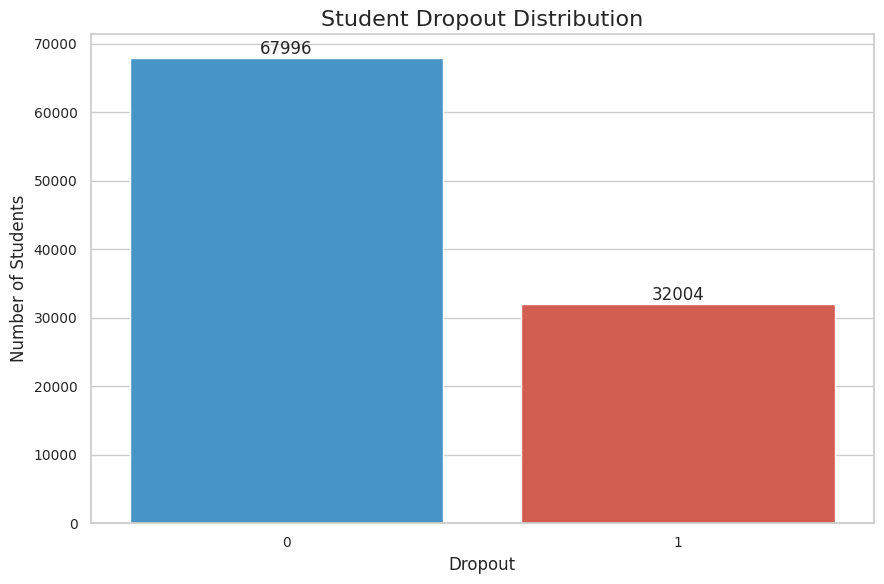

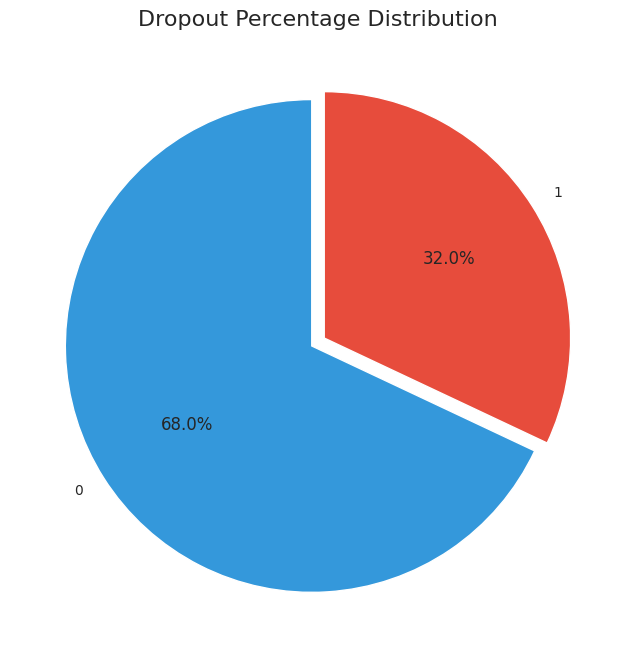


NUMERICAL COLUMNS
['age', 'first_generation', 'disability_status', 'scholarship_holder', 'tuition_up_to_date', 'part_time_job', 'weekly_work_hours', 'semester', 'international_student', 'admission_grade', 'previous_qualification_grade', 'units_enrolled', 'units_passed', 'units_failed', 'gpa_semester_1', 'gpa_semester_2', 'attendance_rate', 'assignments_submitted_rate', 'library_visits_per_month', 'lms_logins_per_week', 'extracurricular_activities', 'missed_deadlines', 'stress_level', 'mental_health_support', 'satisfaction_score', 'commute_time_mins', 'sleep_hours']

CATEGORICAL COLUMNS
['gender', 'nationality', 'family_income_level', 'course_type', 'study_mode']


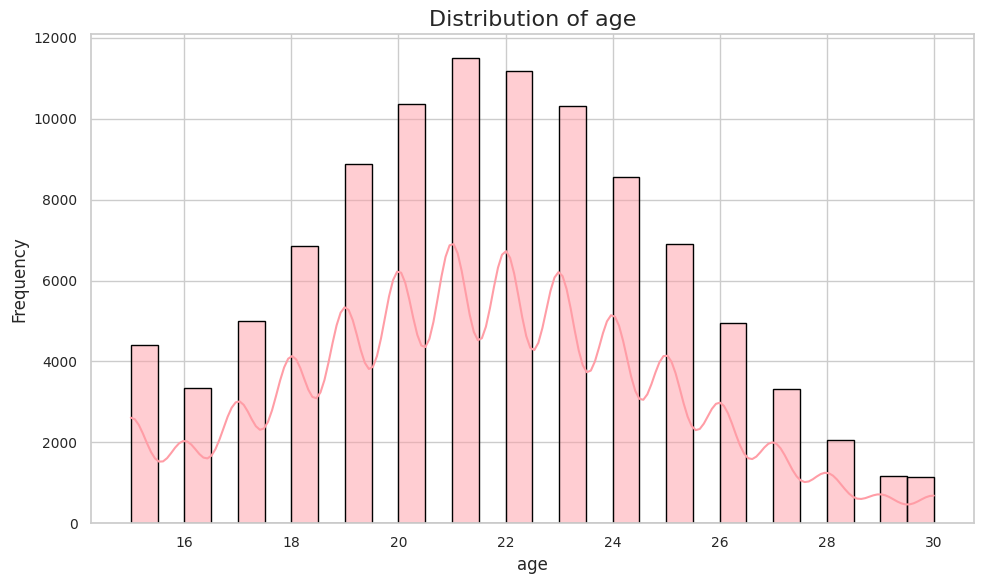

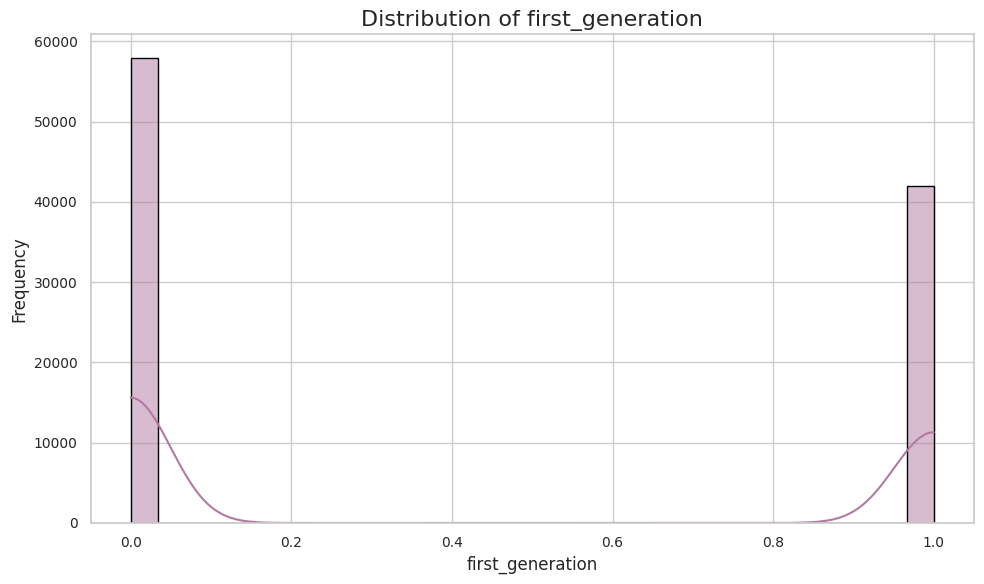

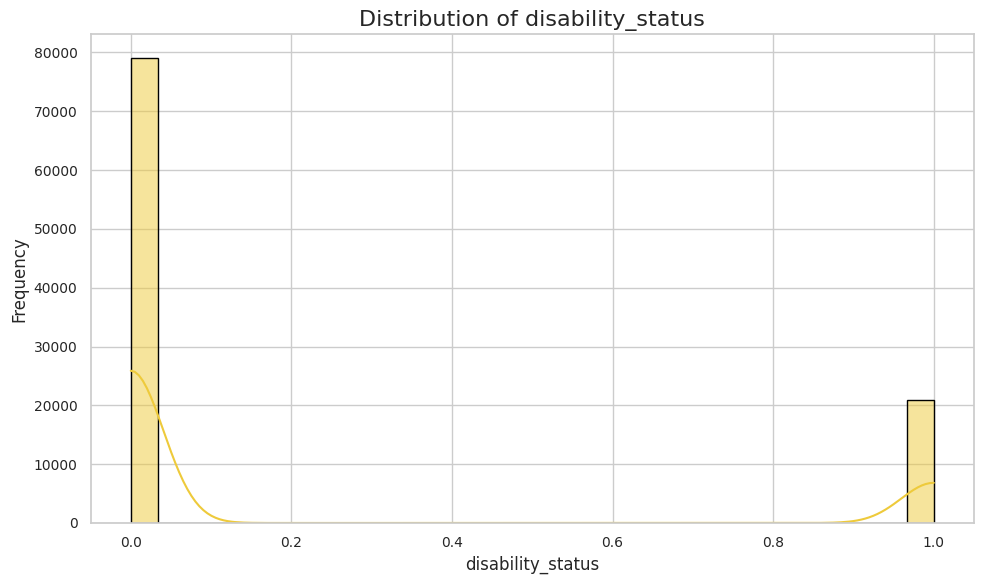

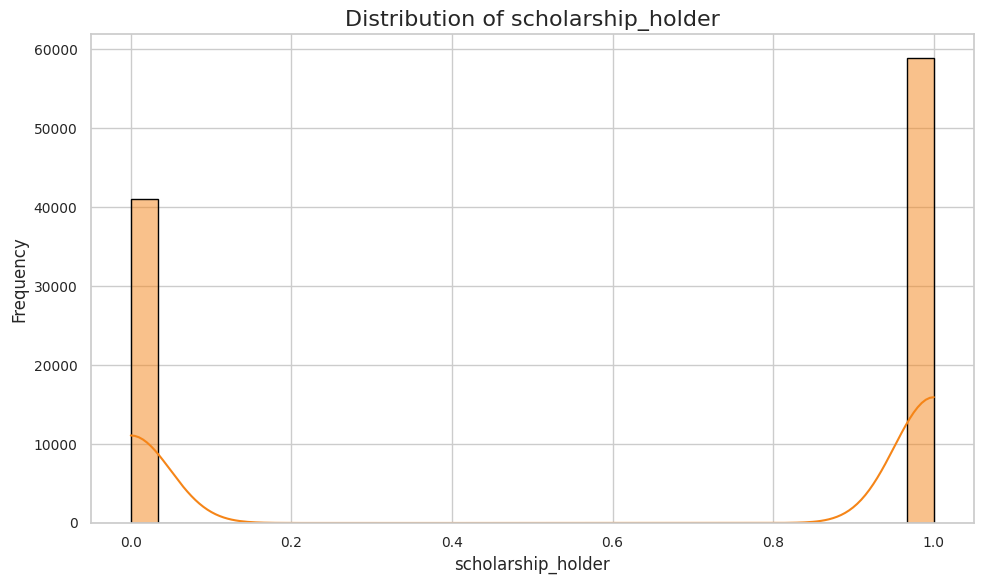

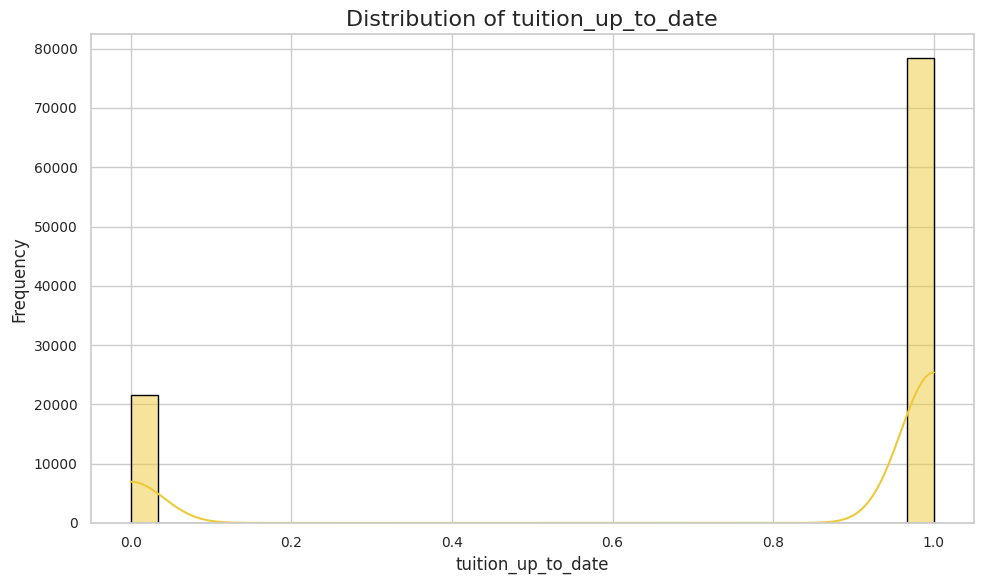

...

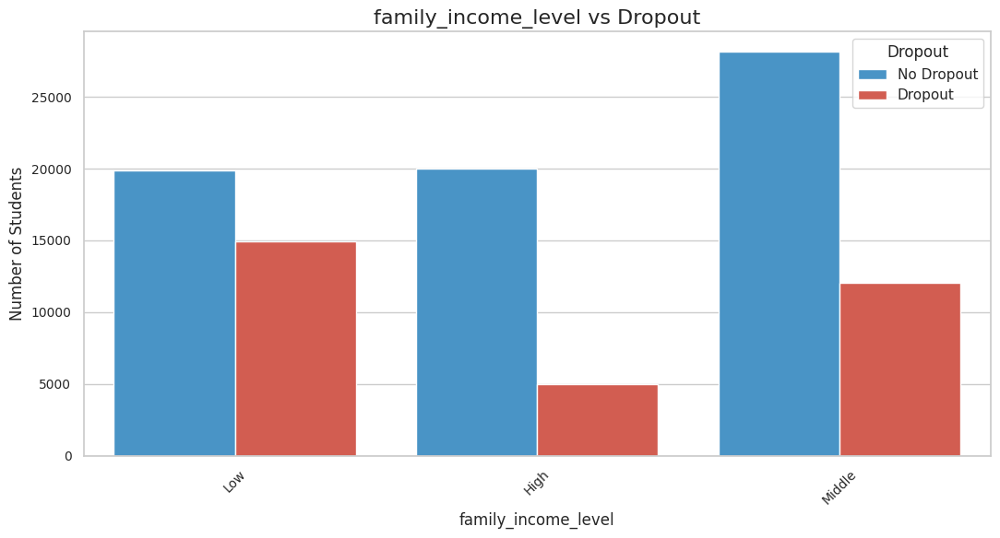

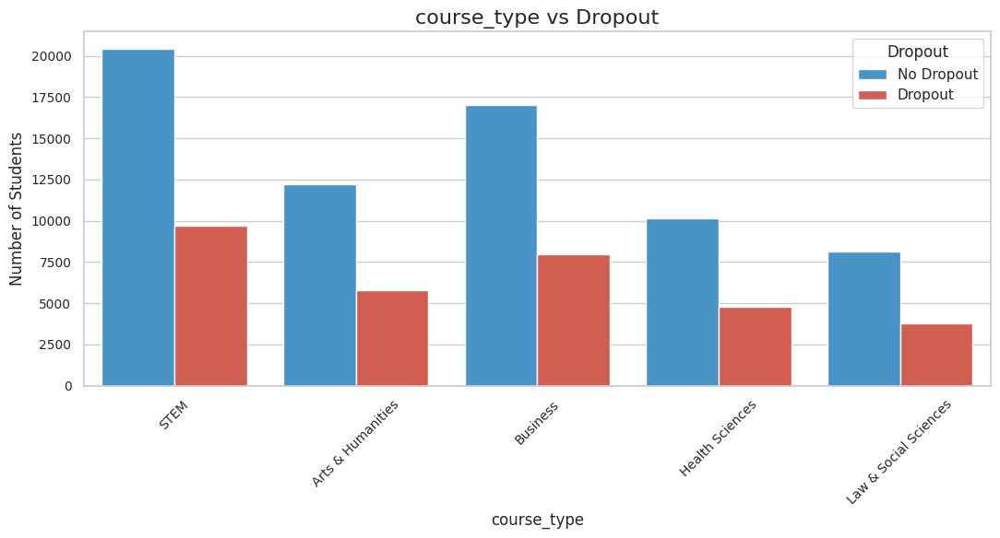

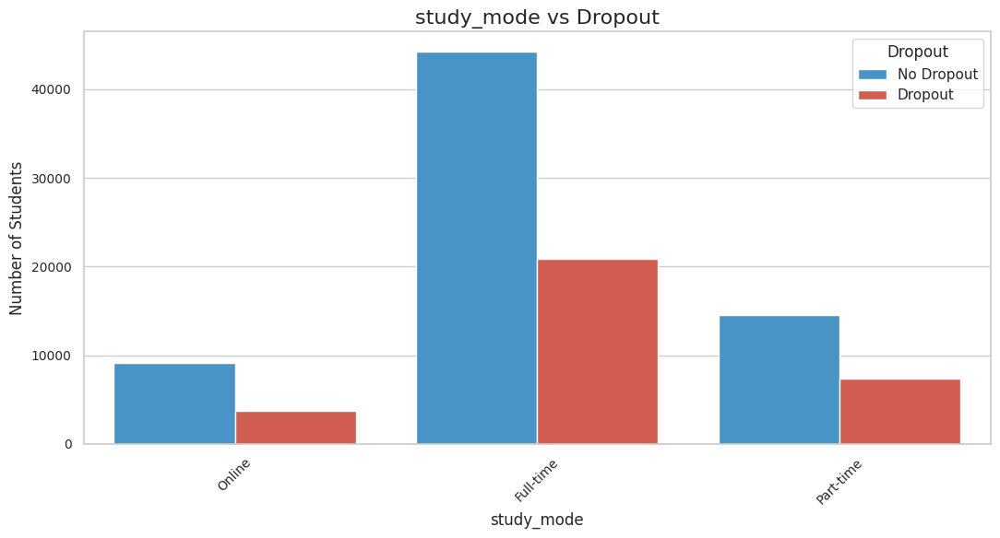

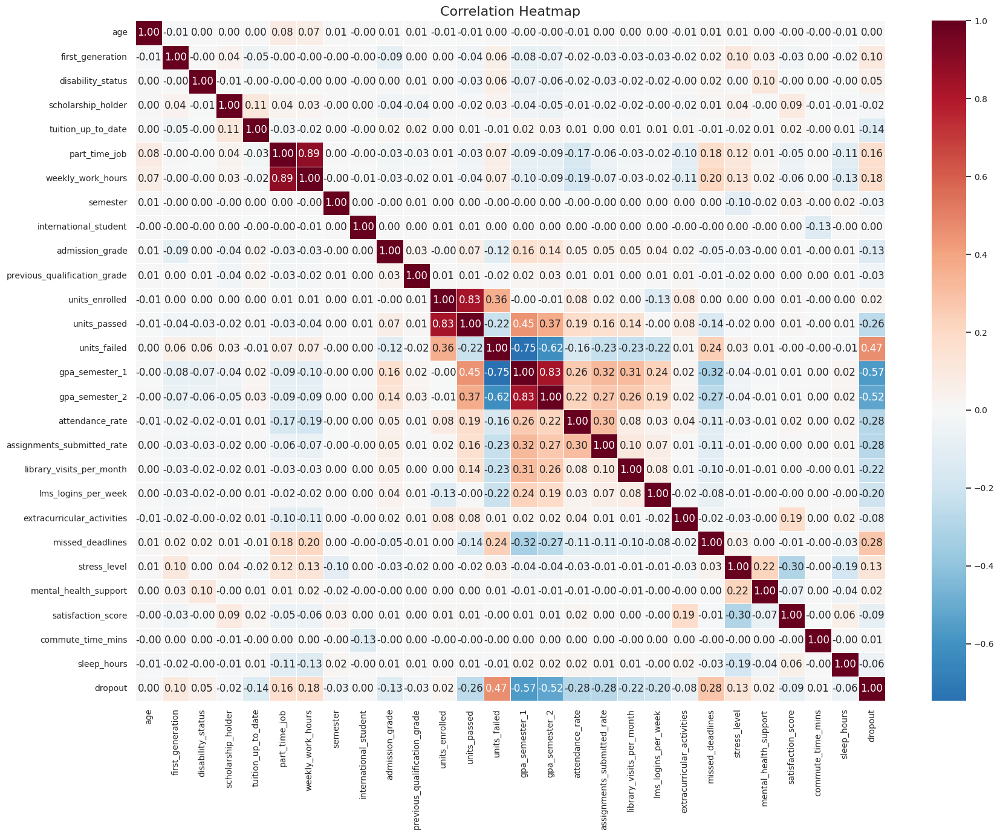

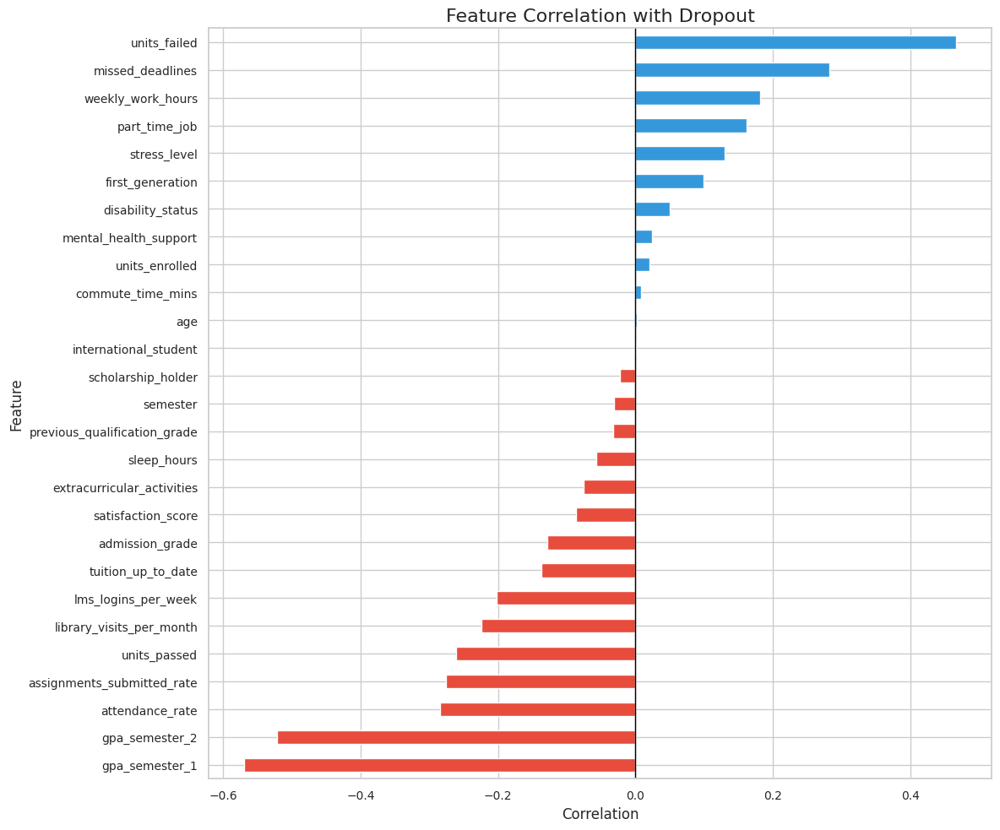


CORRELATION WITH DROPOUT

Most Negative Correlations:


gpa_semester_1               -0.568820
gpa_semester_2               -0.521448
attendance_rate              -0.284607
assignments_submitted_rate   -0.275410
units_passed                 -0.261394
library_visits_per_month     -0.224356
lms_logins_per_week          -0.201643
tuition_up_to_date           -0.137130
admission_grade              -0.128051
satisfaction_score           -0.085987
Name: dropout, dtype: float64


Most Positive Correlations:


units_failed             0.466670
missed_deadlines         0.281921
weekly_work_hours        0.181102
part_time_job            0.161808
stress_level             0.130514
first_generation         0.098986
disability_status        0.049923
mental_health_support    0.024438
units_enrolled           0.020710
commute_time_mins        0.007808
Name: dropout, dtype: float64

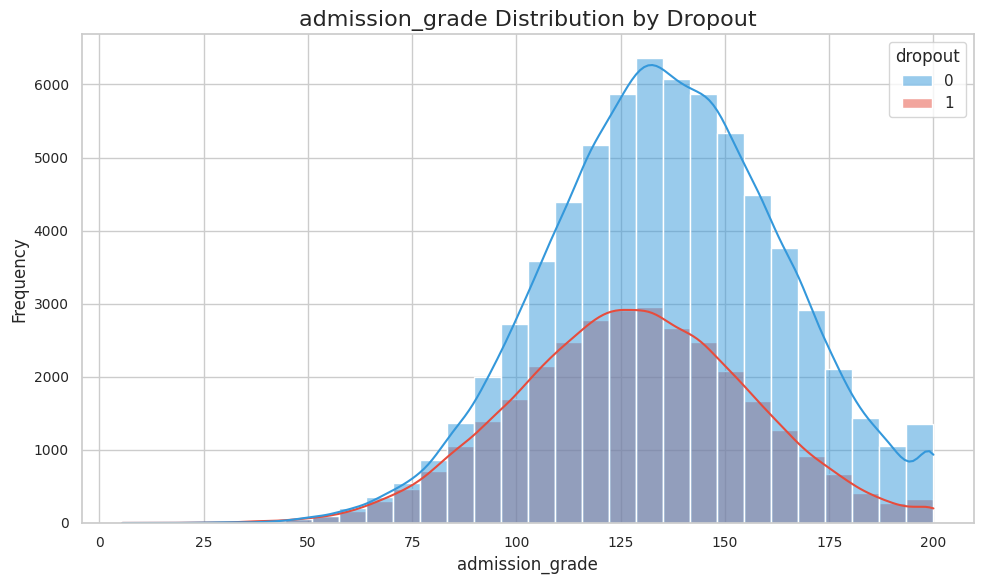

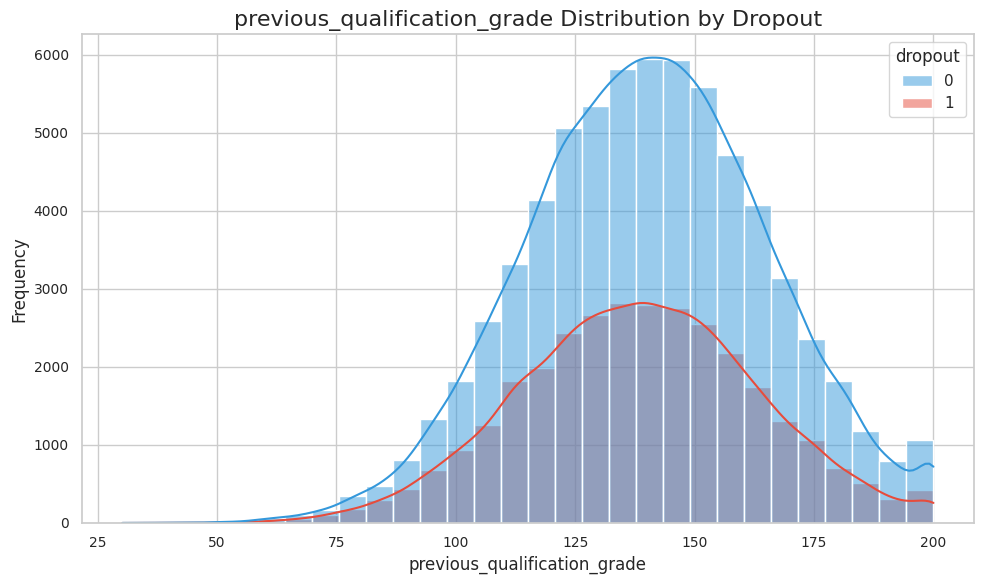

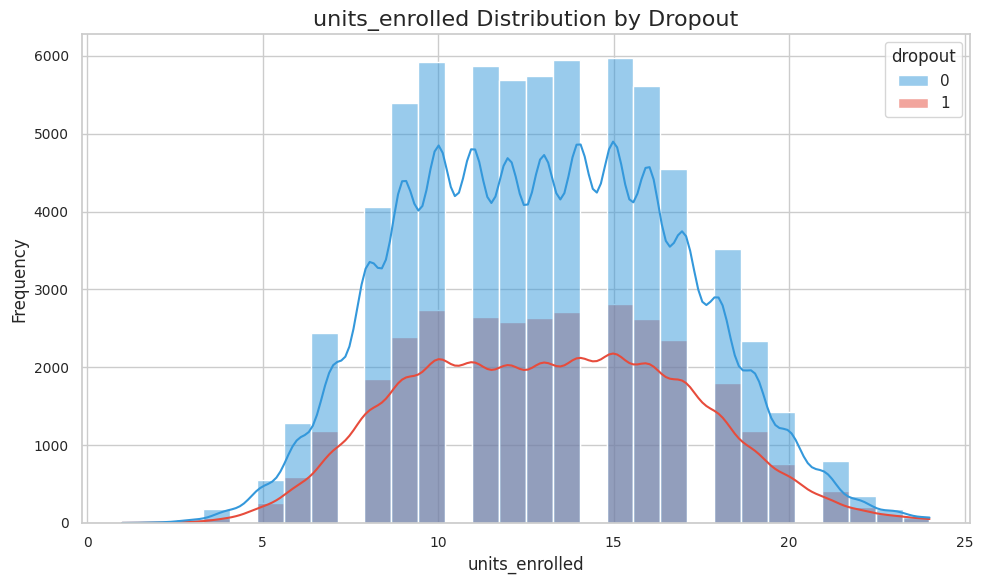

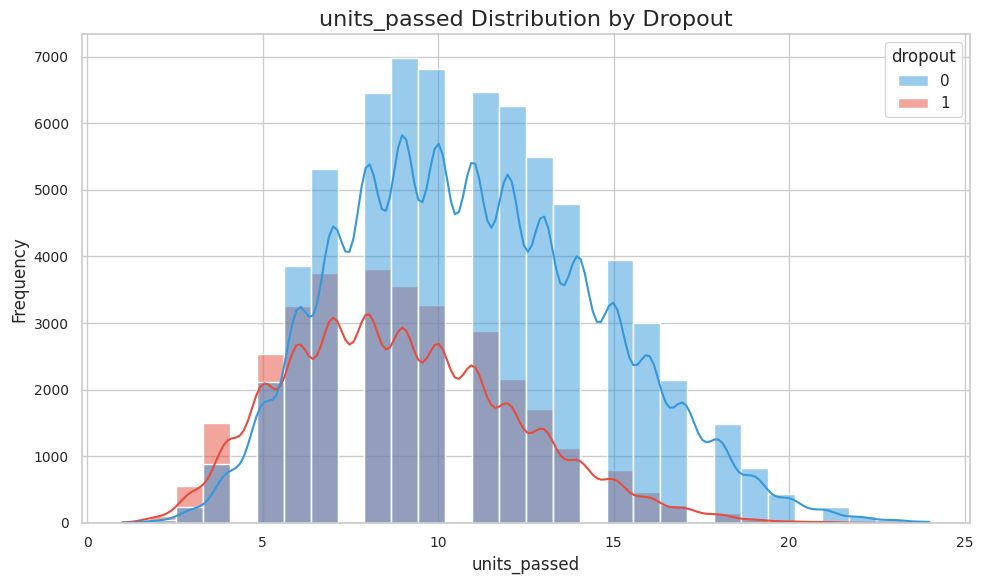

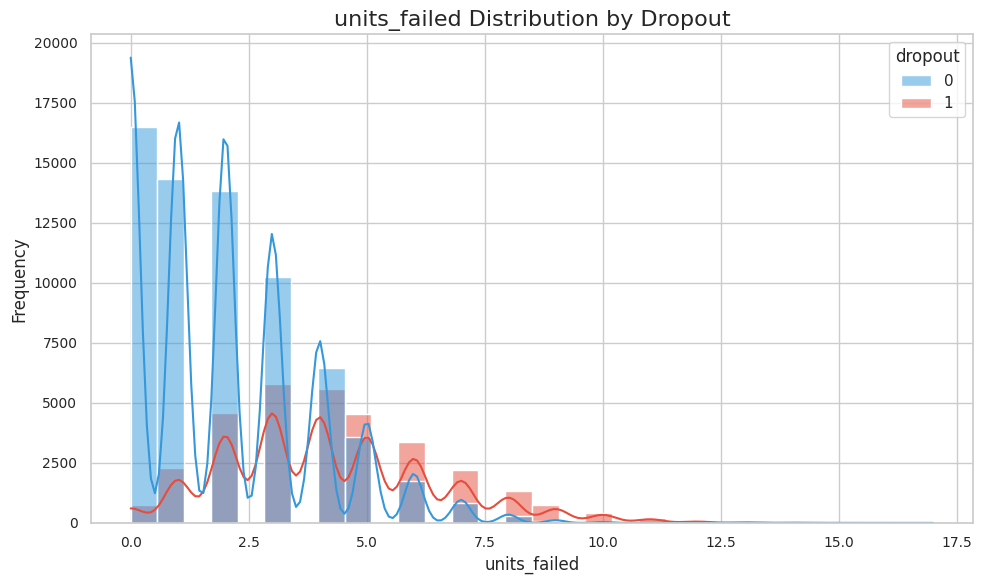

...

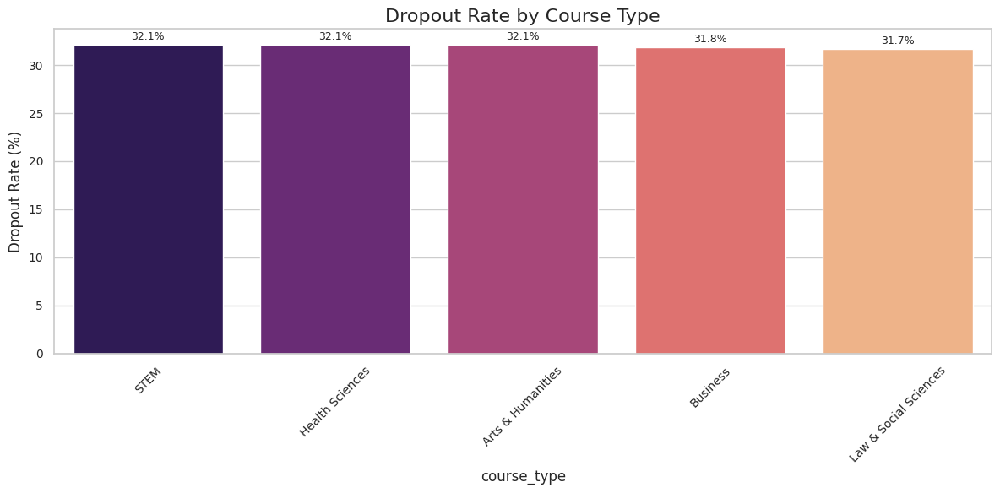

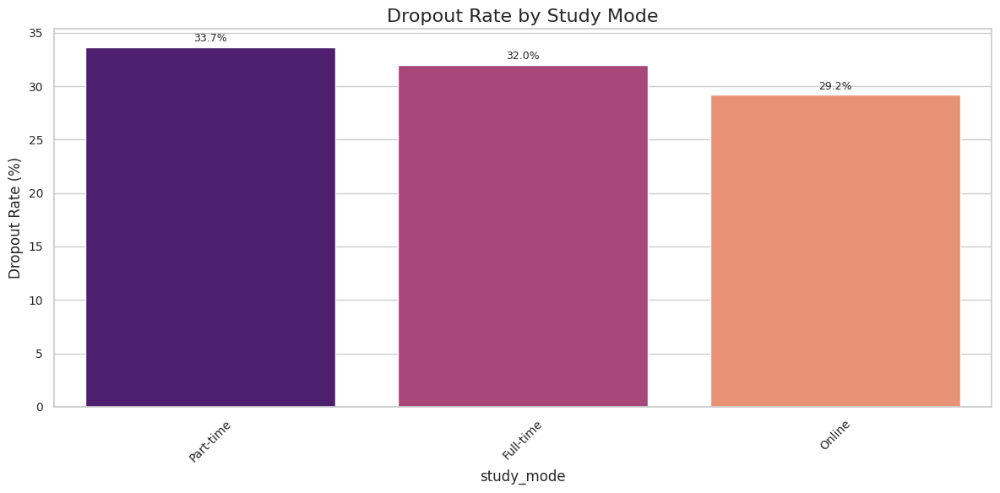

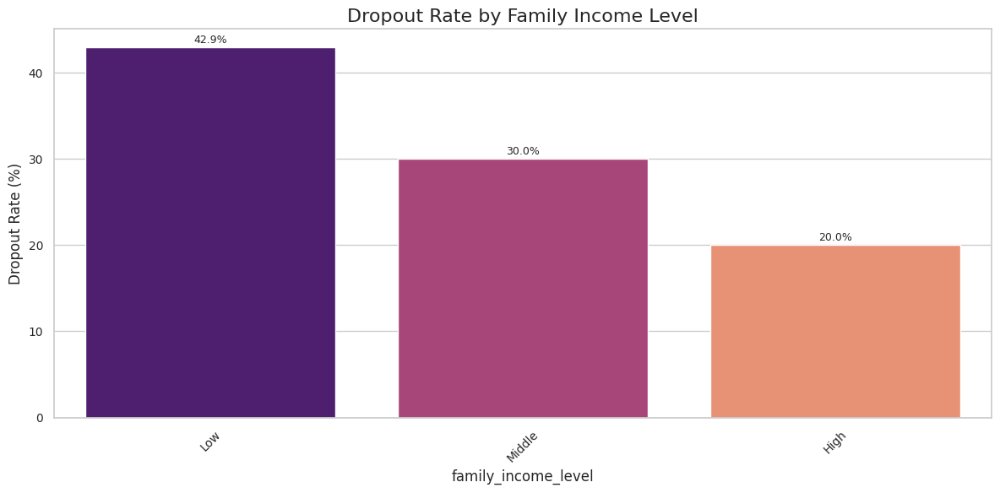

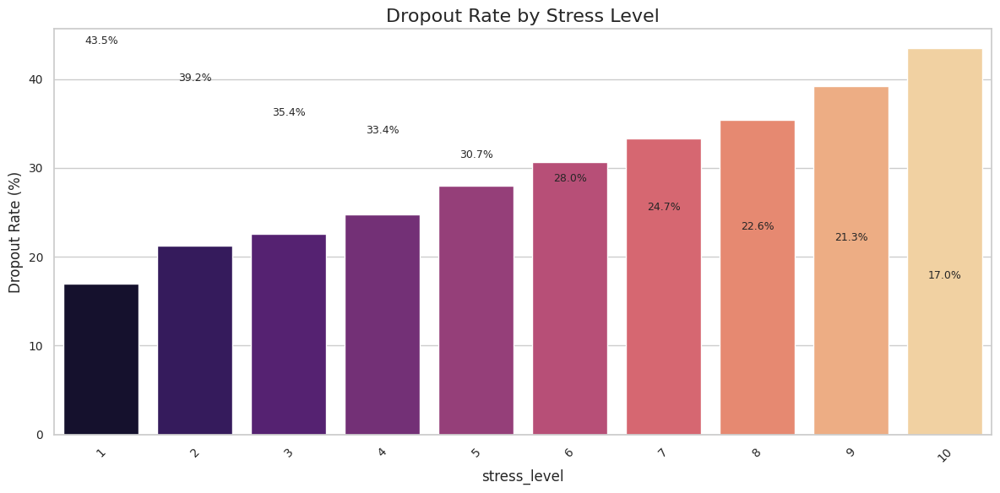

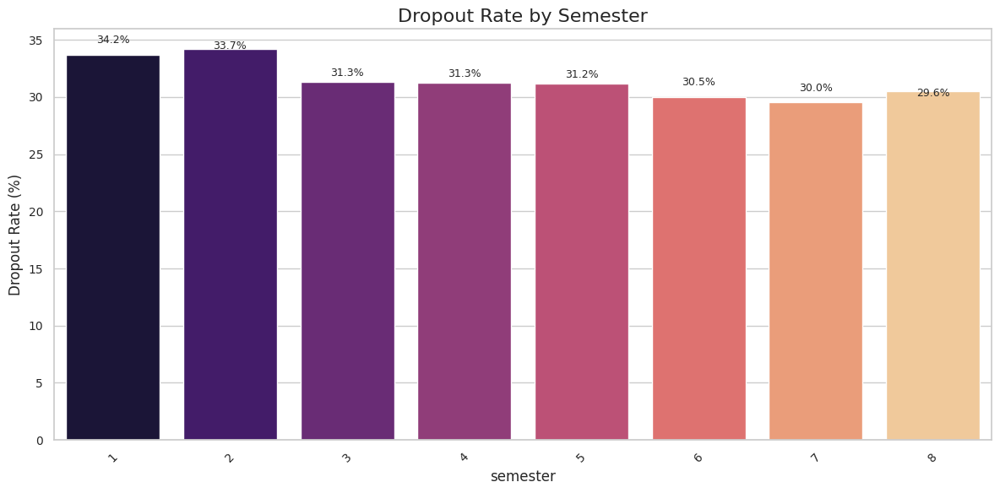


NUMERICAL FEATURE MEANS BY DROPOUT


dropout,0,1
age,21.517045,21.528903
first_generation,0.386611,0.491345
disability_status,0.194850,0.238345
scholarship_holder,0.597212,0.573741
tuition_up_to_date,0.823519,0.702725
part_time_job,0.426452,0.599769
weekly_work_hours,7.473234,11.445819
semester,3.662451,3.523466
international_student,0.180687,0.181477
admission_grade,135.627909,127.871738


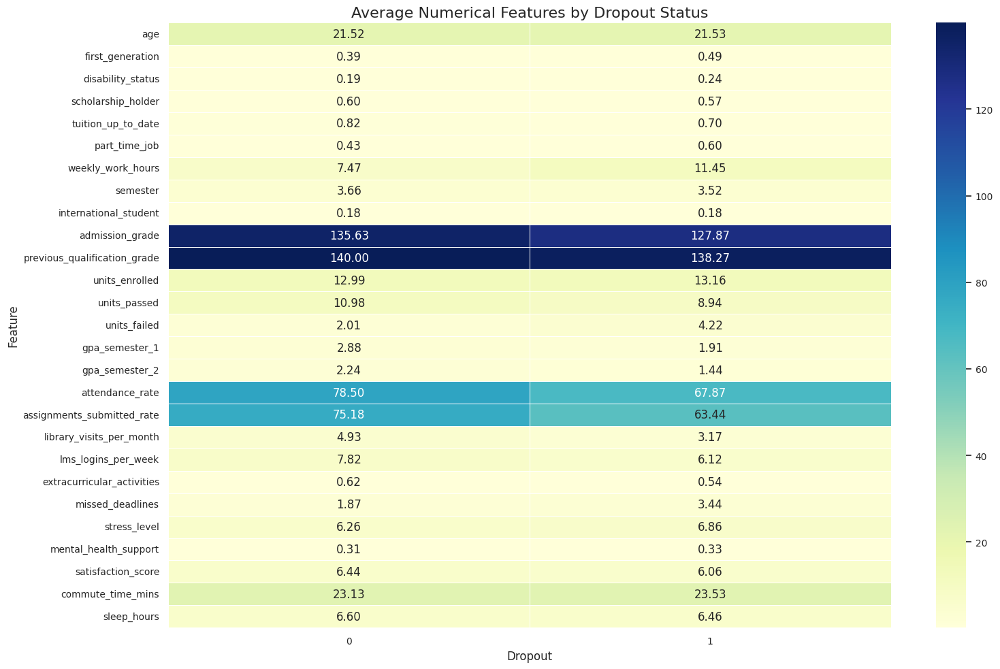

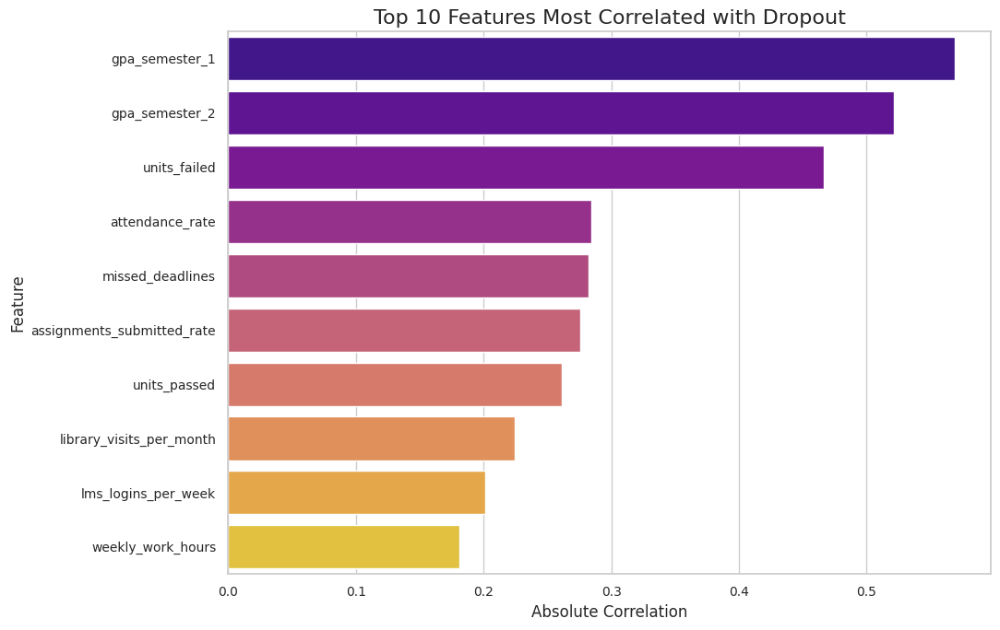

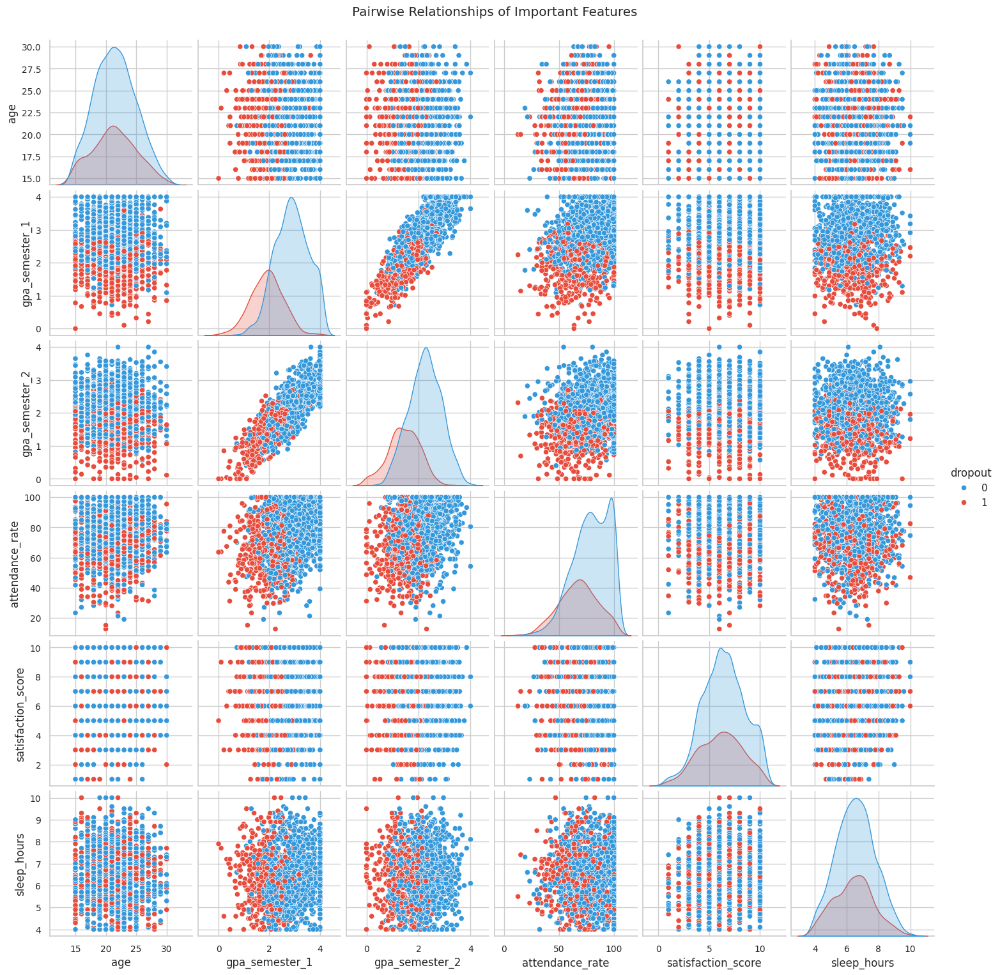



VISUALIZATION COMPLETED
Dataset shape: (100000, 34)

Dropout distribution:
dropout
0    67996
1    32004
Name: count, dtype: int64

Dropout percentage:
dropout
0    68.0
1    32.0
Name: proportion, dtype: float64

Numerical features: 27
Categorical features: 5

All major visualizations have been generated successfully.


In [13]:
from matplotlib.ticker import PercentFormatter

# ------------------------------------------------------------
# 2. PLOT SETTINGS
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Custom color palettes
colors_main = [
    "#4C78A8", "#F58518", "#E45756", "#72B7B2",
    "#54A24B", "#EECA3B", "#B279A2", "#FF9DA6",
    "#9D755D", "#BAB0AC"
]

categorical_palette = [
    "#4C78A8", "#F58518", "#54A24B",
    "#E45756", "#B279A2", "#72B7B2",
    "#FF9DA6", "#EECA3B"
]

dropout_palette = {
    0: "#2E86AB",
    1: "#E74C3C"
}

# ------------------------------------------------------------
# 3. BASIC DATA INFORMATION
# ------------------------------------------------------------

print("=" * 80)
print("DATASET SHAPE")
print("=" * 80)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

print("\n" + "=" * 80)
print("COLUMN INFORMATION")
print("=" * 80)

print(df.info())

print("\n" + "=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)

display(df.head())

print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)

display(df.describe(include="all").T)


# ============================================================
# 4. CHECK MISSING VALUES
# ============================================================

missing = df.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

if len(missing) > 0:

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=missing.values,
        y=missing.index,
        palette="viridis"
    )

    plt.title("Missing Values by Column")
    plt.xlabel("Number of Missing Values")
    plt.ylabel("Column")

    plt.tight_layout()
    plt.show()

else:

    print("\nNo missing values found.")


# ============================================================
# 5. DUPLICATE VALUES
# ============================================================

duplicate_count = df.duplicated().sum()

print("\n" + "=" * 80)
print("DUPLICATE ROWS")
print("=" * 80)

print("Duplicate rows:", duplicate_count)


# ============================================================
# 6. TARGET VARIABLE DISTRIBUTION
# ============================================================

if "dropout" in df.columns:

    print("\n" + "=" * 80)
    print("DROPOUT DISTRIBUTION")
    print("=" * 80)

    print(df["dropout"].value_counts())

    print("\nDropout Percentage:")
    print(
        df["dropout"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    plt.figure(figsize=(9, 6))

    ax = sns.countplot(
        data=df,
        x="dropout",
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Student Dropout Distribution")
    plt.xlabel("Dropout")
    plt.ylabel("Number of Students")

    for container in ax.containers:
        ax.bar_label(container)

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. TARGET PIE CHART
# ============================================================

if "dropout" in df.columns:

    dropout_counts = df["dropout"].value_counts()

    plt.figure(figsize=(8, 8))

    plt.pie(
        dropout_counts.values,
        labels=dropout_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=["#3498DB", "#E74C3C"],
        explode=[0.03] * len(dropout_counts)
    )

    plt.title("Dropout Percentage Distribution")

    plt.show()


# ============================================================
# 8. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ============================================================

numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = df.select_dtypes(
    exclude=np.number
).columns.tolist()

# Remove ID from numerical analysis
if "person_id" in numeric_cols:
    numeric_cols.remove("person_id")

# Remove target from feature analysis
if "dropout" in numeric_cols:
    numeric_cols.remove("dropout")

print("\n" + "=" * 80)
print("NUMERICAL COLUMNS")
print("=" * 80)

print(numeric_cols)

print("\n" + "=" * 80)
print("CATEGORICAL COLUMNS")
print("=" * 80)

print(categorical_cols)


# ============================================================
# 9. HISTOGRAMS FOR ALL NUMERICAL FEATURES
# ============================================================

for col in numeric_cols:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30,
        color=np.random.choice(colors_main),
        edgecolor="black"
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 10. BOXPLOTS FOR NUMERICAL VARIABLES
# ============================================================

for col in numeric_cols:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        x=df[col],
        color=np.random.choice(colors_main)
    )

    plt.title(f"Box Plot - {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()


# ============================================================
# 11. VIOLIN PLOTS
# ============================================================

for col in numeric_cols:

    plt.figure(figsize=(10, 5))

    sns.violinplot(
        x=df[col],
        color=np.random.choice(colors_main)
    )

    plt.title(f"Violin Plot - {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()


# ============================================================
# 12. CATEGORICAL VARIABLE DISTRIBUTIONS
# ============================================================

for col in categorical_cols:

    # Avoid extremely high-cardinality columns
    unique_count = df[col].nunique()

    if unique_count <= 20:

        plt.figure(figsize=(10, 6))

        order = df[col].value_counts().index

        sns.countplot(
            data=df,
            y=col,
            order=order,
            palette="Set2"
        )

        plt.title(f"Distribution of {col}")
        plt.xlabel("Number of Students")
        plt.ylabel(col)

        plt.tight_layout()
        plt.show()


# ============================================================
# 13. DROPOUT VS NUMERICAL VARIABLES
# ============================================================

if "dropout" in df.columns:

    for col in numeric_cols:

        plt.figure(figsize=(10, 6))

        sns.boxplot(
            data=df,
            x="dropout",
            y=col,
            hue="dropout",
            palette=["#3498DB", "#E74C3C"],
            legend=False
        )

        plt.title(f"{col} vs Dropout")
        plt.xlabel("Dropout")
        plt.ylabel(col)

        plt.tight_layout()
        plt.show()


# ============================================================
# 14. DROPOUT VS CATEGORICAL VARIABLES
# ============================================================

if "dropout" in df.columns:

    for col in categorical_cols:

        if df[col].nunique() <= 15:

            plt.figure(figsize=(11, 6))

            sns.countplot(
                data=df,
                x=col,
                hue="dropout",
                palette={
                    0: "#3498DB",
                    1: "#E74C3C"
                }
            )

            plt.title(f"{col} vs Dropout")
            plt.xlabel(col)
            plt.ylabel("Number of Students")

            plt.xticks(rotation=45)

            plt.legend(
                title="Dropout",
                labels=["No Dropout", "Dropout"]
            )

            plt.tight_layout()
            plt.show()


# ============================================================
# 15. CORRELATION MATRIX
# ============================================================

correlation_cols = numeric_cols.copy()

if "dropout" in df.columns:
    correlation_cols.append("dropout")

corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=False
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()


# ============================================================
# 16. CORRELATION WITH DROPOUT
# ============================================================

if "dropout" in df.columns:

    dropout_corr = (
        df[correlation_cols]
        .corr()["dropout"]
        .drop("dropout")
        .sort_values()
    )

    plt.figure(figsize=(12, 10))

    dropout_corr.plot(
        kind="barh",
        color=[
            "#E74C3C" if x < 0 else "#3498DB"
            for x in dropout_corr.values
        ]
    )

    plt.axvline(
        0,
        color="black",
        linewidth=1
    )

    plt.title("Feature Correlation with Dropout")
    plt.xlabel("Correlation")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()


# ============================================================
# 17. TOP POSITIVE / NEGATIVE CORRELATIONS
# ============================================================

if "dropout" in df.columns:

    print("\n" + "=" * 80)
    print("CORRELATION WITH DROPOUT")
    print("=" * 80)

    print("\nMost Negative Correlations:")
    display(dropout_corr.head(10))

    print("\nMost Positive Correlations:")
    display(dropout_corr.tail(10).sort_values(ascending=False))


# ============================================================
# 18. IMPORTANT ACADEMIC FEATURES
# ============================================================

academic_features = [
    "admission_grade",
    "previous_qualification_grade",
    "units_enrolled",
    "units_passed",
    "units_failed",
    "gpa_semester_1",
    "gpa_semester_2",
    "attendance_rate",
    "assignments_submitted_rate",
    "missed_deadlines"
]

academic_features = [
    col for col in academic_features
    if col in df.columns
]


# ============================================================
# 19. ACADEMIC FEATURES DISTRIBUTION
# ============================================================

for col in academic_features:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x=col,
        hue="dropout" if "dropout" in df.columns else None,
        kde=True,
        bins=30,
        palette=["#3498DB", "#E74C3C"]
        if "dropout" in df.columns else None
    )

    plt.title(f"{col} Distribution by Dropout")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 20. GPA ANALYSIS
# ============================================================

gpa_cols = [
    col for col in [
        "gpa_semester_1",
        "gpa_semester_2"
    ]
    if col in df.columns
]

if len(gpa_cols) > 0:

    plt.figure(figsize=(12, 6))

    for col in gpa_cols:

        sns.kdeplot(
            data=df,
            x=col,
            fill=True,
            alpha=0.25,
            linewidth=2,
            label=col
        )

    plt.title("GPA Distribution")
    plt.xlabel("GPA")
    plt.ylabel("Density")

    plt.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# 21. GPA vs DROPOUT
# ============================================================

for col in gpa_cols:

    if "dropout" in df.columns:

        plt.figure(figsize=(9, 6))

        sns.boxplot(
            data=df,
            x="dropout",
            y=col,
            hue="dropout",
            palette=["#2ECC71", "#E74C3C"],
            legend=False
        )

        sns.stripplot(
            data=df.sample(
                min(2000, len(df)),
                random_state=42
            ),
            x="dropout",
            y=col,
            color="black",
            alpha=0.15
        )

        plt.title(f"{col} vs Dropout")
        plt.xlabel("Dropout")
        plt.ylabel(col)

        plt.tight_layout()
        plt.show()


# ============================================================
# 22. ATTENDANCE ANALYSIS
# ============================================================

if "attendance_rate" in df.columns:

    plt.figure(figsize=(11, 6))

    sns.histplot(
        data=df,
        x="attendance_rate",
        hue="dropout",
        bins=30,
        kde=True,
        palette=["#3498DB", "#E74C3C"],
        element="step"
    )

    plt.title("Attendance Rate vs Dropout")
    plt.xlabel("Attendance Rate")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 23. ATTENDANCE BOXPLOT
# ============================================================

if all(
    col in df.columns
    for col in ["attendance_rate", "dropout"]
):

    plt.figure(figsize=(9, 6))

    sns.boxplot(
        data=df,
        x="dropout",
        y="attendance_rate",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"],
        legend=False
    )

    plt.title("Attendance Rate by Dropout Status")
    plt.xlabel("Dropout")
    plt.ylabel("Attendance Rate")

    plt.tight_layout()
    plt.show()


# ============================================================
# 24. STRESS LEVEL ANALYSIS
# ============================================================

if "stress_level" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x="stress_level",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Stress Level vs Dropout")
    plt.xlabel("Stress Level")
    plt.ylabel("Number of Students")

    plt.legend(
        title="Dropout",
        labels=["No Dropout", "Dropout"]
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 25. SATISFACTION SCORE
# ============================================================

if "satisfaction_score" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x="satisfaction_score",
        hue="dropout",
        kde=True,
        bins=20,
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Satisfaction Score vs Dropout")
    plt.xlabel("Satisfaction Score")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 26. SLEEP HOURS
# ============================================================

if "sleep_hours" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.violinplot(
        data=df,
        x="dropout",
        y="sleep_hours",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"],
        legend=False
    )

    plt.title("Sleep Hours vs Dropout")
    plt.xlabel("Dropout")
    plt.ylabel("Sleep Hours")

    plt.tight_layout()
    plt.show()


# ============================================================
# 27. WORKING HOURS
# ============================================================

if all(
    col in df.columns
    for col in ["weekly_work_hours", "dropout"]
):

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x="dropout",
        y="weekly_work_hours",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"],
        legend=False
    )

    plt.title("Weekly Work Hours vs Dropout")
    plt.xlabel("Dropout")
    plt.ylabel("Weekly Work Hours")

    plt.tight_layout()
    plt.show()


# ============================================================
# 28. AGE DISTRIBUTION
# ============================================================

if "age" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df,
        x="age",
        hue="dropout",
        kde=True,
        bins=20,
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Age Distribution by Dropout")
    plt.xlabel("Age")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 29. GENDER VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["gender", "dropout"]
):

    plt.figure(figsize=(9, 6))

    sns.countplot(
        data=df,
        x="gender",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Gender vs Dropout")
    plt.xlabel("Gender")
    plt.ylabel("Number of Students")

    plt.legend(
        title="Dropout",
        labels=["No Dropout", "Dropout"]
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 30. COURSE TYPE VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["course_type", "dropout"]
):

    plt.figure(figsize=(12, 7))

    order = (
        df["course_type"]
        .value_counts()
        .index
    )

    sns.countplot(
        data=df,
        y="course_type",
        hue="dropout",
        order=order,
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Course Type vs Dropout")
    plt.xlabel("Number of Students")
    plt.ylabel("Course Type")

    plt.tight_layout()
    plt.show()


# ============================================================
# 31. STUDY MODE VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["study_mode", "dropout"]
):

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x="study_mode",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Study Mode vs Dropout")
    plt.xlabel("Study Mode")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 32. SCHOLARSHIP VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["scholarship_holder", "dropout"]
):

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x="scholarship_holder",
        hue="dropout",
        palette=["#2ECC71", "#E74C3C"]
    )

    plt.title("Scholarship Holder vs Dropout")
    plt.xlabel("Scholarship Holder")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 33. TUITION STATUS VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["tuition_up_to_date", "dropout"]
):

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x="tuition_up_to_date",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Tuition Status vs Dropout")
    plt.xlabel("Tuition Up To Date")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 34. PART-TIME JOB VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["part_time_job", "dropout"]
):

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x="part_time_job",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Part-Time Job vs Dropout")
    plt.xlabel("Part-Time Job")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 35. FIRST GENERATION VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["first_generation", "dropout"]
):

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x="first_generation",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("First Generation Student vs Dropout")
    plt.xlabel("First Generation")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 36. INTERNATIONAL STUDENT VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["international_student", "dropout"]
):

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x="international_student",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("International Student vs Dropout")
    plt.xlabel("International Student")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 37. MENTAL HEALTH SUPPORT VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["mental_health_support", "dropout"]
):

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x="mental_health_support",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Mental Health Support vs Dropout")
    plt.xlabel("Mental Health Support")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 38. LMS LOGINS VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["lms_logins_per_week", "dropout"]
):

    plt.figure(figsize=(11, 6))

    sns.histplot(
        data=df,
        x="lms_logins_per_week",
        hue="dropout",
        bins=25,
        kde=True,
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("LMS Logins per Week vs Dropout")
    plt.xlabel("LMS Logins per Week")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 39. LIBRARY VISITS VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["library_visits_per_month", "dropout"]
):

    plt.figure(figsize=(11, 6))

    sns.histplot(
        data=df,
        x="library_visits_per_month",
        hue="dropout",
        bins=25,
        kde=True,
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Library Visits per Month vs Dropout")
    plt.xlabel("Library Visits per Month")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 40. MISSED DEADLINES VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["missed_deadlines", "dropout"]
):

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x="dropout",
        y="missed_deadlines",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"],
        legend=False
    )

    plt.title("Missed Deadlines vs Dropout")
    plt.xlabel("Dropout")
    plt.ylabel("Missed Deadlines")

    plt.tight_layout()
    plt.show()


# ============================================================
# 41. UNITS PASSED VS UNITS FAILED
# ============================================================

if all(
    col in df.columns
    for col in ["units_passed", "units_failed", "dropout"]
):

    plt.figure(figsize=(11, 7))

    sns.scatterplot(
        data=df.sample(
            min(5000, len(df)),
            random_state=42
        ),
        x="units_passed",
        y="units_failed",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"],
        alpha=0.65,
        s=60
    )

    plt.title("Units Passed vs Units Failed")
    plt.xlabel("Units Passed")
    plt.ylabel("Units Failed")

    plt.tight_layout()
    plt.show()


# ============================================================
# 42. GPA SEMESTER 1 VS GPA SEMESTER 2
# ============================================================

if all(
    col in df.columns
    for col in [
        "gpa_semester_1",
        "gpa_semester_2",
        "dropout"
    ]
):

    plt.figure(figsize=(11, 7))

    sns.scatterplot(
        data=df.sample(
            min(5000, len(df)),
            random_state=42
        ),
        x="gpa_semester_1",
        y="gpa_semester_2",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"],
        alpha=0.65
    )

    plt.title("Semester 1 GPA vs Semester 2 GPA")
    plt.xlabel("GPA Semester 1")
    plt.ylabel("GPA Semester 2")

    plt.tight_layout()
    plt.show()


# ============================================================
# 43. ATTENDANCE VS GPA
# ============================================================

if all(
    col in df.columns
    for col in [
        "attendance_rate",
        "gpa_semester_2",
        "dropout"
    ]
):

    plt.figure(figsize=(11, 7))

    sns.scatterplot(
        data=df.sample(
            min(5000, len(df)),
            random_state=42
        ),
        x="attendance_rate",
        y="gpa_semester_2",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"],
        alpha=0.6,
        s=60
    )

    plt.title("Attendance Rate vs Semester 2 GPA")
    plt.xlabel("Attendance Rate")
    plt.ylabel("GPA Semester 2")

    plt.tight_layout()
    plt.show()


# ============================================================
# 44. STRESS VS SATISFACTION
# ============================================================

if all(
    col in df.columns
    for col in [
        "stress_level",
        "satisfaction_score",
        "dropout"
    ]
):

    plt.figure(figsize=(11, 7))

    sns.scatterplot(
        data=df.sample(
            min(5000, len(df)),
            random_state=42
        ),
        x="stress_level",
        y="satisfaction_score",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"],
        alpha=0.6,
        s=60
    )

    plt.title("Stress Level vs Satisfaction Score")
    plt.xlabel("Stress Level")
    plt.ylabel("Satisfaction Score")

    plt.tight_layout()
    plt.show()


# ============================================================
# 45. SEMESTER VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["semester", "dropout"]
):

    plt.figure(figsize=(11, 6))

    sns.countplot(
        data=df,
        x="semester",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Semester vs Dropout")
    plt.xlabel("Semester")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 46. FAMILY INCOME VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["family_income_level", "dropout"]
):

    plt.figure(figsize=(11, 6))

    sns.countplot(
        data=df,
        x="family_income_level",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Family Income Level vs Dropout")
    plt.xlabel("Family Income Level")
    plt.ylabel("Number of Students")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 47. DISABILITY STATUS VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["disability_status", "dropout"]
):

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x="disability_status",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Disability Status vs Dropout")
    plt.xlabel("Disability Status")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 48. NATIONALITY VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["nationality", "dropout"]
):

    top_nationalities = (
        df["nationality"]
        .value_counts()
        .head(15)
        .index
    )

    temp = df[
        df["nationality"].isin(top_nationalities)
    ]

    plt.figure(figsize=(13, 7))

    sns.countplot(
        data=temp,
        y="nationality",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Top Nationalities vs Dropout")
    plt.xlabel("Number of Students")
    plt.ylabel("Nationality")

    plt.tight_layout()
    plt.show()


# ============================================================
# 49. EXTRACURRICULAR ACTIVITIES VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["extracurricular_activities", "dropout"]
):

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x="extracurricular_activities",
        hue="dropout",
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Extracurricular Activities vs Dropout")
    plt.xlabel("Extracurricular Activities")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 50. COMMUTE TIME VS DROPOUT
# ============================================================

if all(
    col in df.columns
    for col in ["commute_time_mins", "dropout"]
):

    plt.figure(figsize=(11, 6))

    sns.histplot(
        data=df,
        x="commute_time_mins",
        hue="dropout",
        bins=30,
        kde=True,
        palette=["#3498DB", "#E74C3C"]
    )

    plt.title("Commute Time vs Dropout")
    plt.xlabel("Commute Time (Minutes)")
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()


# ============================================================
# 51. GROUPED DROPOUT RATE ANALYSIS
# ============================================================

def plot_dropout_rate(column, title):

    if column not in df.columns or "dropout" not in df.columns:
        return

    temp = (
        df.groupby(column)["dropout"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    temp["dropout_rate"] = temp["dropout"] * 100

    if len(temp) > 20:
        temp = temp.head(20)

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=temp,
        x=column,
        y="dropout_rate",
        palette="magma"
    )

    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Dropout Rate (%)")

    plt.xticks(rotation=45)

    for i, value in enumerate(temp["dropout_rate"]):
        plt.text(
            i,
            value + 0.5,
            f"{value:.1f}%",
            ha="center",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


# Apply dropout-rate analysis
plot_dropout_rate(
    "gender",
    "Dropout Rate by Gender"
)

plot_dropout_rate(
    "course_type",
    "Dropout Rate by Course Type"
)

plot_dropout_rate(
    "study_mode",
    "Dropout Rate by Study Mode"
)

plot_dropout_rate(
    "family_income_level",
    "Dropout Rate by Family Income Level"
)

plot_dropout_rate(
    "stress_level",
    "Dropout Rate by Stress Level"
)

plot_dropout_rate(
    "semester",
    "Dropout Rate by Semester"
)


# ============================================================
# 52. NUMERICAL FEATURE MEANS BY DROPOUT
# ============================================================

if "dropout" in df.columns:

    mean_by_dropout = (
        df.groupby("dropout")[numeric_cols]
        .mean()
        .T
    )

    print("\n" + "=" * 80)
    print("NUMERICAL FEATURE MEANS BY DROPOUT")
    print("=" * 80)

    display(mean_by_dropout)


# ============================================================
# 53. HEATMAP OF MEAN NUMERICAL FEATURES BY DROPOUT
# ============================================================

if "dropout" in df.columns:

    mean_data = (
        df.groupby("dropout")[numeric_cols]
        .mean()
    )

    plt.figure(figsize=(16, 10))

    sns.heatmap(
        mean_data.T,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        linewidths=0.5
    )

    plt.title(
        "Average Numerical Features by Dropout Status"
    )

    plt.xlabel("Dropout")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()


# ============================================================
# 54. TOP 10 FEATURES WITH HIGHEST CORRELATION
# ============================================================

if "dropout" in df.columns:

    abs_corr = (
        dropout_corr
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(11, 7))

    sns.barplot(
        x=abs_corr.values,
        y=abs_corr.index,
        palette="plasma"
    )

    plt.title(
        "Top 10 Features Most Correlated with Dropout"
    )

    plt.xlabel("Absolute Correlation")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()


# ============================================================
# 55. PAIRPLOT FOR IMPORTANT FEATURES
# ============================================================

pair_features = [
    "age",
    "gpa_semester_1",
    "gpa_semester_2",
    "attendance_rate",
    "satisfaction_score",
    "sleep_hours",
    "dropout"
]

pair_features = [
    col for col in pair_features
    if col in df.columns
]

if len(pair_features) >= 3:

    pair_sample = df[
        pair_features
    ].sample(
        min(1500, len(df)),
        random_state=42
    )

    sns.pairplot(
        pair_sample,
        hue="dropout" if "dropout" in pair_sample.columns else None,
        palette=["#3498DB", "#E74C3C"]
        if "dropout" in pair_sample.columns else None,
        diag_kind="kde"
    )

    plt.suptitle(
        "Pairwise Relationships of Important Features",
        y=1.02
    )

    plt.show()


# ============================================================
# 56. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("VISUALIZATION COMPLETED")
print("=" * 80)

print("Dataset shape:", df.shape)

if "dropout" in df.columns:

    print(
        "\nDropout distribution:"
    )

    print(
        df["dropout"]
        .value_counts()
    )

    print(
        "\nDropout percentage:"
    )

    print(
        df["dropout"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

print("\nNumerical features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

print("\nAll major visualizations have been generated successfully.")

## Feature engineering

ML CONFIGURATION
Target column : dropout
Test size     : 0.2
Train size    : 0.8
Random state  : 42

Dataset shape: (100000, 34)

Target values:
dropout
0    67996
1    32004
Name: count, dtype: int64

Duplicate rows removed: 0

Removed identifier column: person_id

TARGET ENCODING
Original target classes:
['0' '1']

Encoded target classes:
0 -> 0
1 -> 1

Number of target classes: 2

TRAIN TEST SPLIT
X_train: (80000, 32)
X_test : (20000, 32)
y_train: (80000,)
y_test : (20000,)

FEATURE TYPES

Numerical features:
['age', 'first_generation', 'disability_status', 'scholarship_holder', 'tuition_up_to_date', 'part_time_job', 'weekly_work_hours', 'semester', 'international_student', 'admission_grade', 'previous_qualification_grade', 'units_enrolled', 'units_passed', 'units_failed', 'gpa_semester_1', 'gpa_semester_2', 'attendance_rate', 'assignments_submitted_rate', 'library_visits_per_month', 'lms_logins_per_week', 'extracurricular_activities', 'missed_deadlines', 'stress_level', 'mental_hea

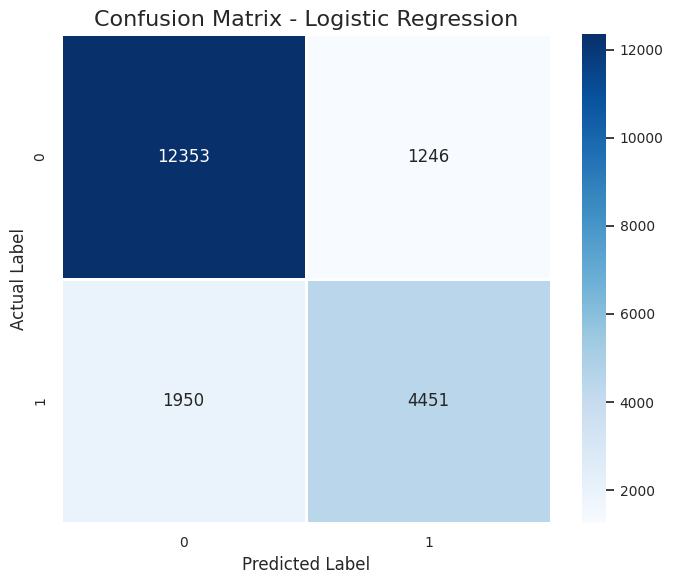



TRAINING: Decision Tree

Accuracy  : 80.58%
Precision : 73.24%
Recall    : 61.99%
F1 Score  : 67.15%
ROC-AUC   : 85.75%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86     13599
           1       0.73      0.62      0.67      6401

    accuracy                           0.81     20000
   macro avg       0.78      0.76      0.77     20000
weighted avg       0.80      0.81      0.80     20000



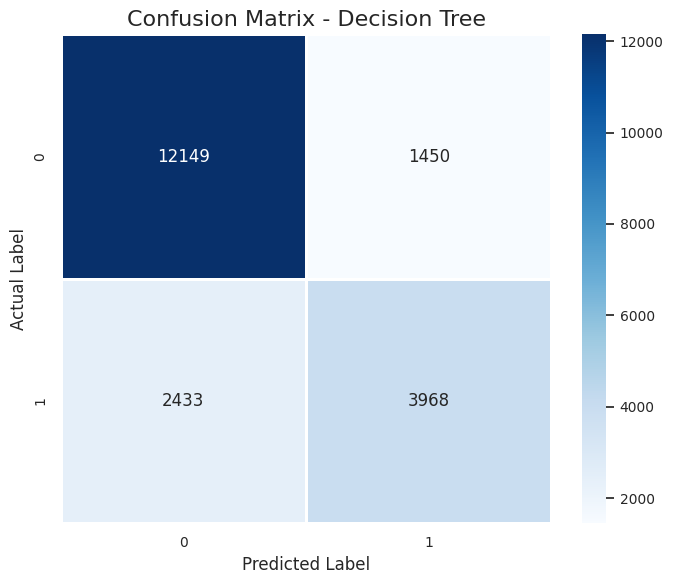



TRAINING: Random Forest

Accuracy  : 82.67%
Precision : 72.37%
Recall    : 74.19%
F1 Score  : 73.27%
ROC-AUC   : 89.52%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87     13599
           1       0.72      0.74      0.73      6401

    accuracy                           0.83     20000
   macro avg       0.80      0.80      0.80     20000
weighted avg       0.83      0.83      0.83     20000



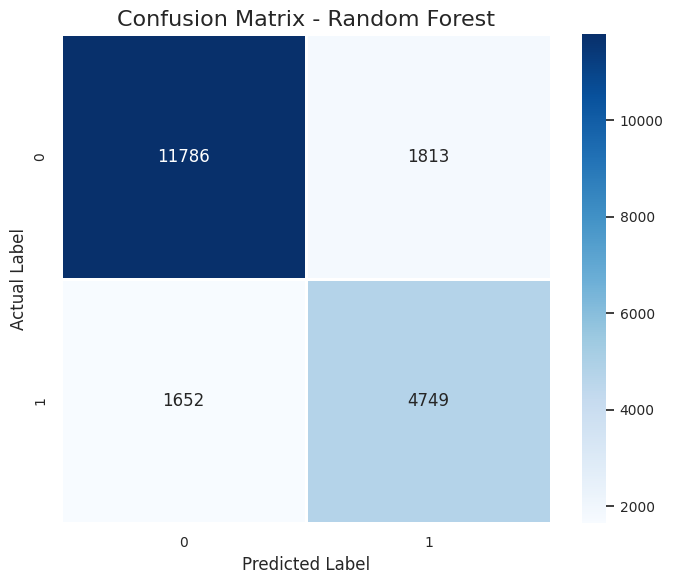



TRAINING: Gradient Boosting

Accuracy  : 83.71%
Precision : 78.13%
Recall    : 68.19%
F1 Score  : 72.82%
ROC-AUC   : 90.04%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88     13599
           1       0.78      0.68      0.73      6401

    accuracy                           0.84     20000
   macro avg       0.82      0.80      0.81     20000
weighted avg       0.83      0.84      0.83     20000



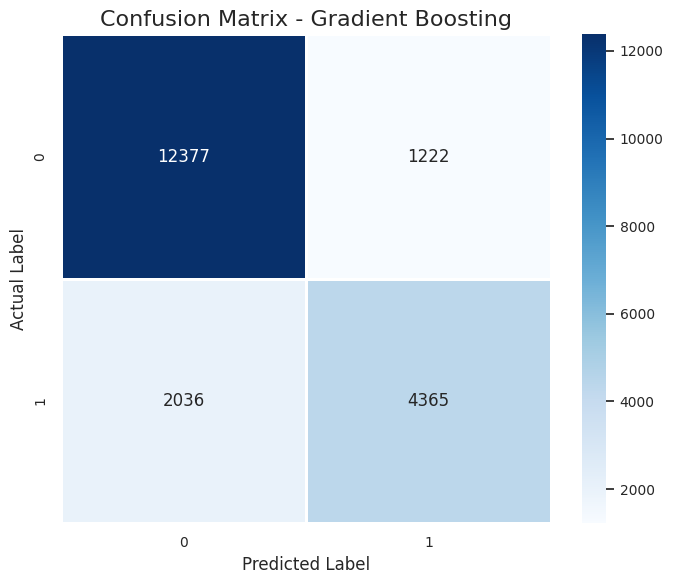



TRAINING: KNN

Accuracy  : 80.55%
Precision : 74.74%
Recall    : 59.23%
F1 Score  : 66.09%
ROC-AUC   : 85.05%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.86     13599
           1       0.75      0.59      0.66      6401

    accuracy                           0.81     20000
   macro avg       0.79      0.75      0.76     20000
weighted avg       0.80      0.81      0.80     20000



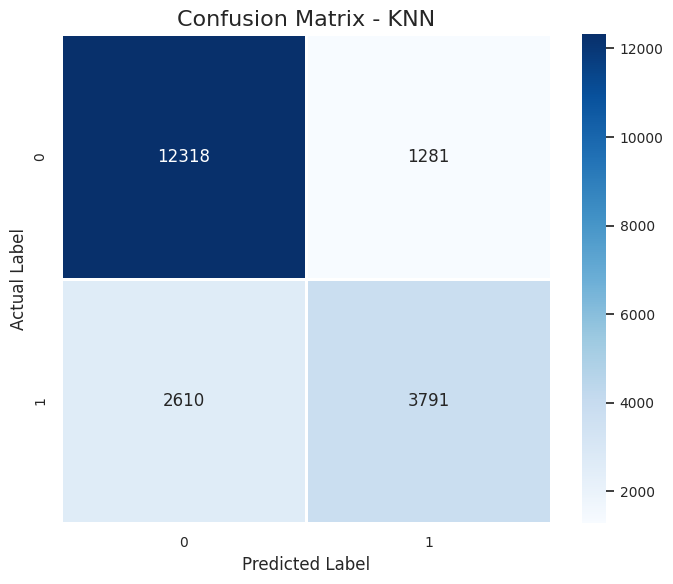



TRAINING: XGBoost

Accuracy  : 83.83%
Precision : 77.84%
Recall    : 69.16%
F1 Score  : 73.25%
ROC-AUC   : 90.06%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88     13599
           1       0.78      0.69      0.73      6401

    accuracy                           0.84     20000
   macro avg       0.82      0.80      0.81     20000
weighted avg       0.84      0.84      0.84     20000



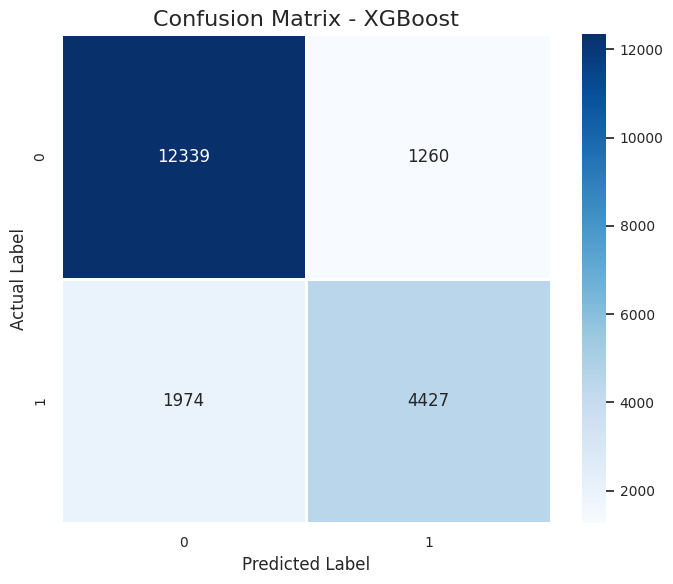



TRAINING: LightGBM

Accuracy  : 83.84%
Precision : 77.65%
Recall    : 69.52%
F1 Score  : 73.36%
ROC-AUC   : 90.08%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88     13599
           1       0.78      0.70      0.73      6401

    accuracy                           0.84     20000
   macro avg       0.82      0.80      0.81     20000
weighted avg       0.84      0.84      0.84     20000



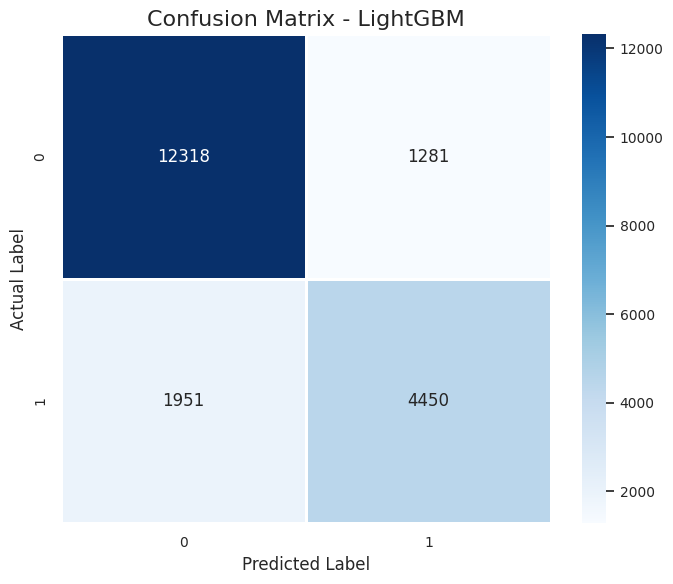



TRAINING: CatBoost

Accuracy  : 83.99%
Precision : 78.41%
Recall    : 68.97%
F1 Score  : 73.39%
ROC-AUC   : 90.24%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.89     13599
           1       0.78      0.69      0.73      6401

    accuracy                           0.84     20000
   macro avg       0.82      0.80      0.81     20000
weighted avg       0.84      0.84      0.84     20000



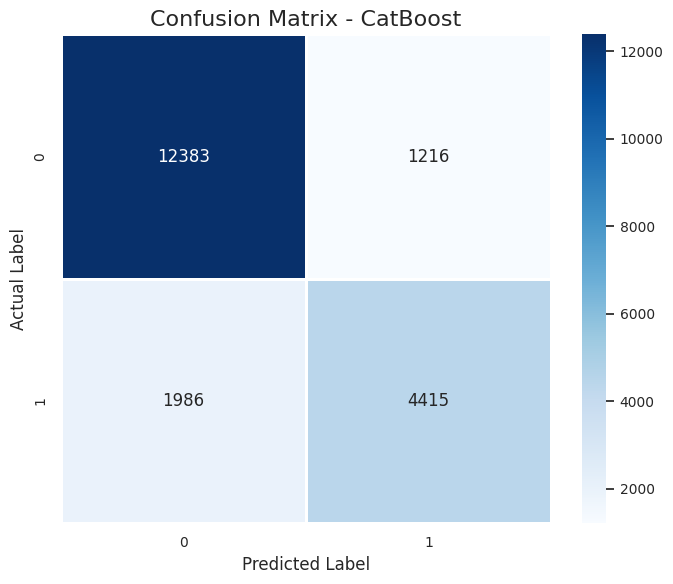


MODEL PERFORMANCE COMPARISON


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC-AUC (%)
0,Logistic Regression,84.02,78.13,69.54,73.58,90.31
1,CatBoost,83.99,78.41,68.97,73.39,90.24
2,LightGBM,83.84,77.65,69.52,73.36,90.08
3,XGBoost,83.83,77.84,69.16,73.25,90.06
4,Gradient Boosting,83.71,78.13,68.19,72.82,90.04
5,Random Forest,82.68,72.37,74.19,73.27,89.52
6,Decision Tree,80.58,73.24,61.99,67.15,85.75
7,KNN,80.54,74.74,59.23,66.09,85.05


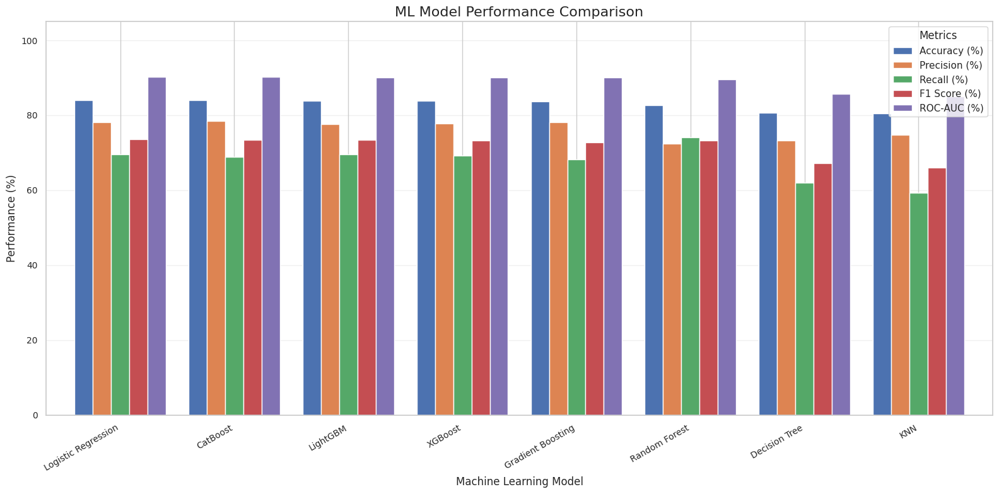

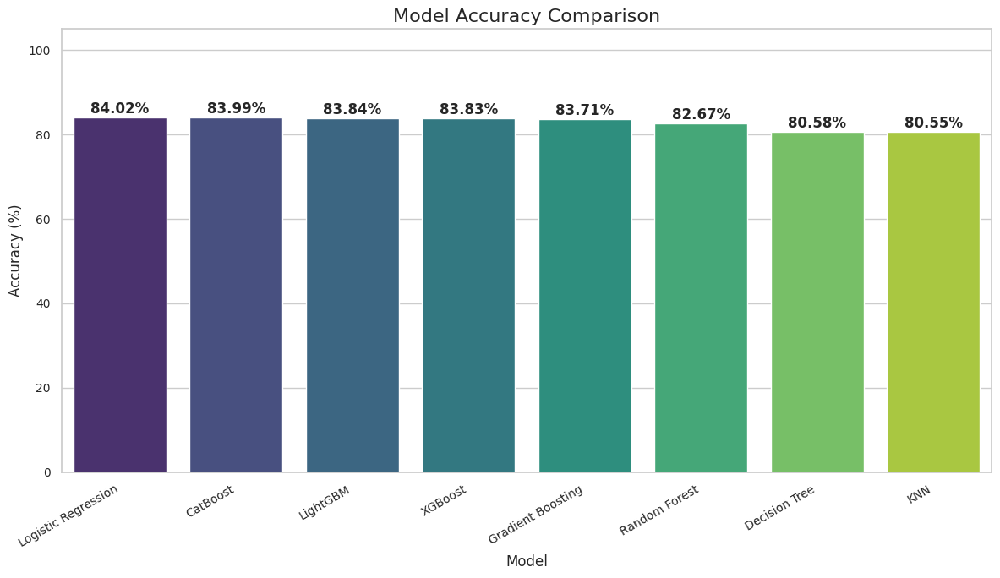

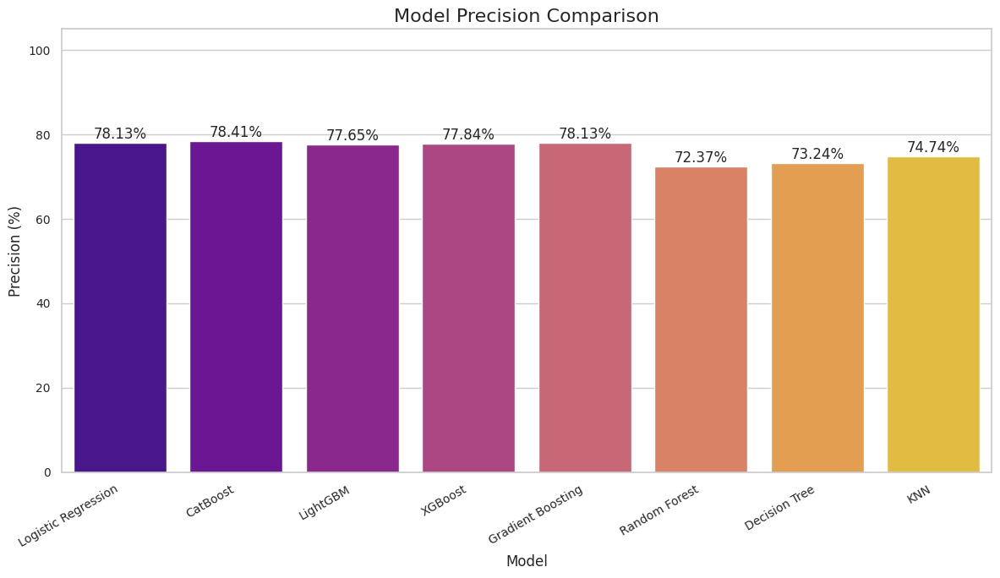

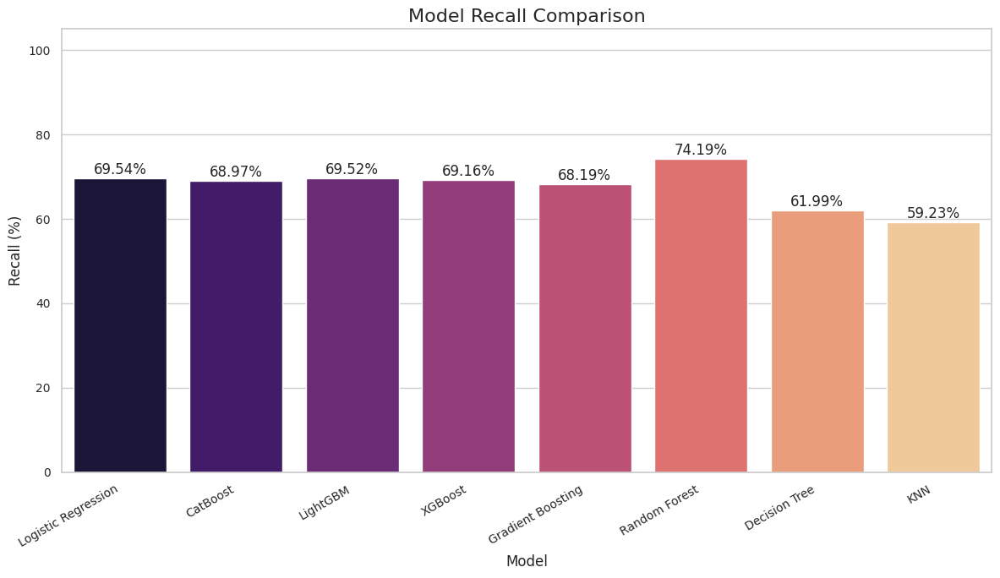

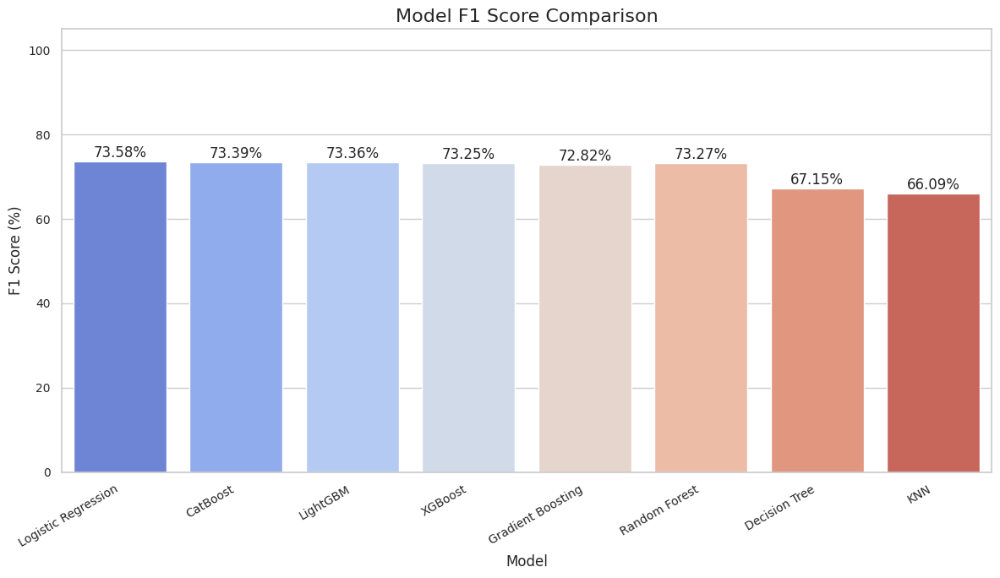

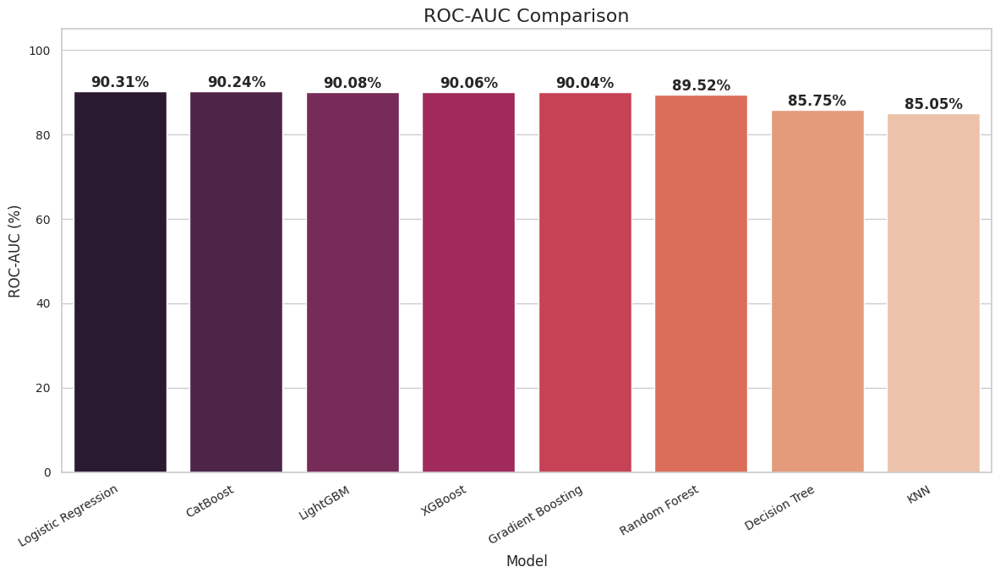

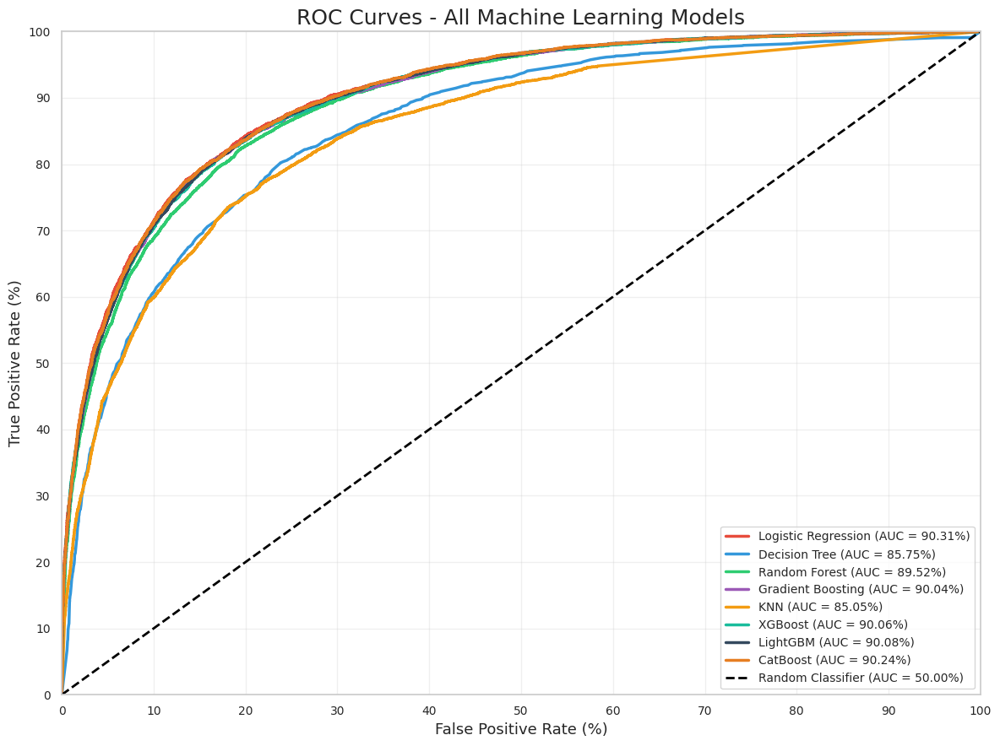


BEST MODEL
Model     : Logistic Regression
Accuracy  : 84.02%
Precision : 78.13%
Recall    : 69.54%
F1 Score  : 73.58%
ROC-AUC   : 90.31%


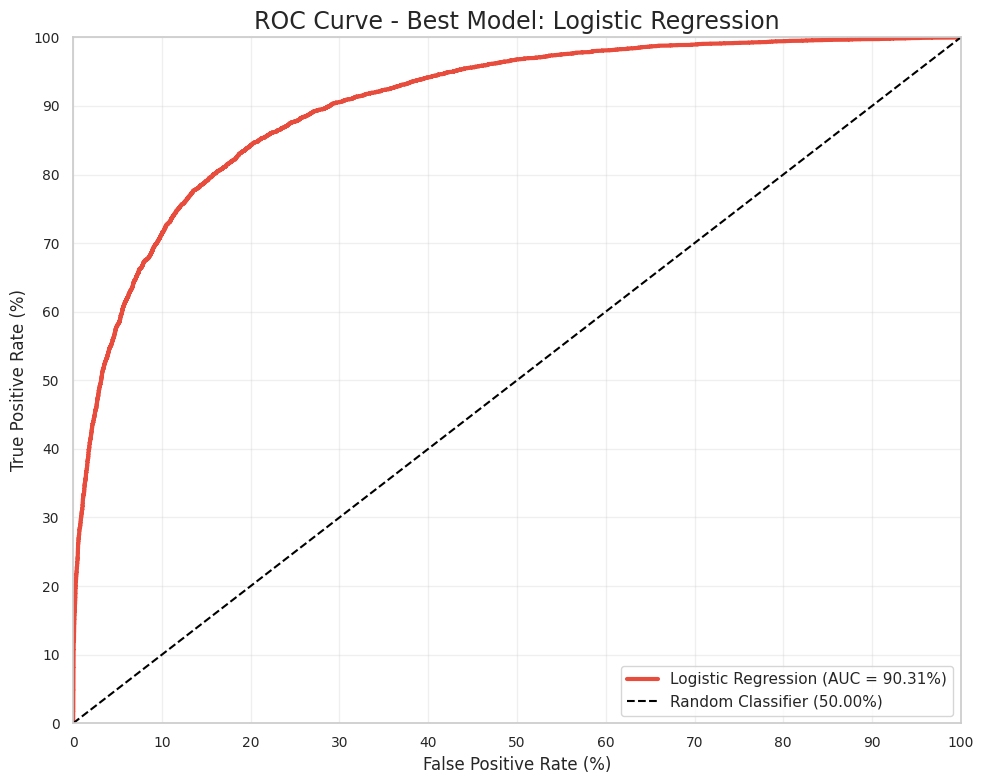


Number of transformed features:
56

TOP 20 FEATURES - Logistic Regression


,Feature,Importance
14,numeric__gpa_semester_1,0.909316
45,categorical__family_income_level_High,0.567917
15,numeric__gpa_semester_2,0.557319
16,numeric__attendance_rate,0.430682
4,numeric__tuition_up_to_date,0.384943
53,categorical__study_mode_Full-time,0.325600
19,numeric__lms_logins_per_week,0.320395
21,numeric__missed_deadlines,0.316545
6,numeric__weekly_work_hours,0.290725
17,numeric__assignments_submitted_rate,0.282539


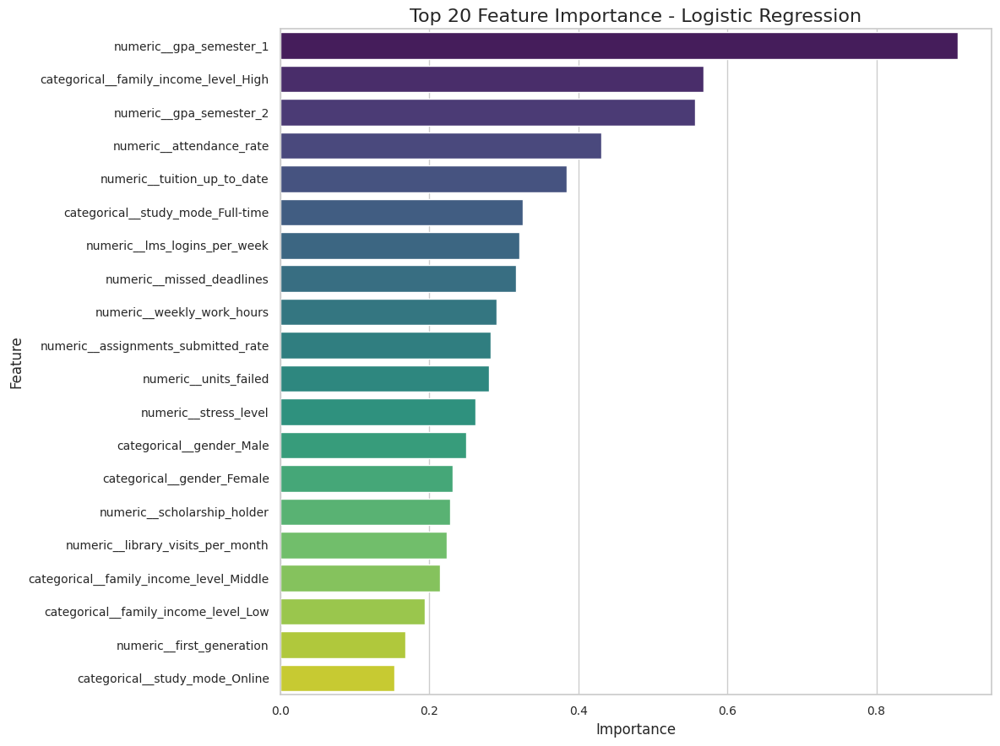



FINAL ML SUMMARY


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC-AUC (%)
0,Logistic Regression,84.02,78.13,69.54,73.58,90.31
1,CatBoost,83.99,78.41,68.97,73.39,90.24
2,LightGBM,83.84,77.65,69.52,73.36,90.08
3,XGBoost,83.83,77.84,69.16,73.25,90.06
4,Gradient Boosting,83.71,78.13,68.19,72.82,90.04
5,Random Forest,82.68,72.37,74.19,73.27,89.52
6,Decision Tree,80.58,73.24,61.99,67.15,85.75
7,KNN,80.54,74.74,59.23,66.09,85.05



Best model based on ROC-AUC: Logistic Regression
Best ROC-AUC: 90.31%
Best Accuracy: 84.02%
Best Precision: 78.13%
Best Recall: 69.54%
Best F1 Score: 73.58%

ML pipeline completed successfully.


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Optional ML algorithms
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except:
    lgbm_available = False

try:
    from catboost import CatBoostClassifier
    catboost_available = True
except:
    catboost_available = False


# ================================================================
# 2. SETTINGS
# ================================================================

TARGET = "dropout"

TEST_SIZE = 0.20
RANDOM_STATE = 42

print("=" * 80)
print("ML CONFIGURATION")
print("=" * 80)

print("Target column :", TARGET)
print("Test size     :", TEST_SIZE)
print("Train size    :", 1 - TEST_SIZE)
print("Random state  :", RANDOM_STATE)


# ================================================================
# 3. CHECK DATA
# ================================================================

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' was not found in df."
    )

print("\nDataset shape:", df.shape)

print("\nTarget values:")
print(df[TARGET].value_counts(dropna=False))


# ================================================================
# 4. REMOVE DUPLICATE ROWS
# ================================================================

df_ml = df.copy()

before = len(df_ml)

df_ml = df_ml.drop_duplicates().reset_index(drop=True)

after = len(df_ml)

print("\nDuplicate rows removed:", before - after)


# ================================================================
# 5. REMOVE ROWS WHERE TARGET IS MISSING
# ================================================================

df_ml = df_ml.dropna(
    subset=[TARGET]
).reset_index(drop=True)


# ================================================================
# 6. SEPARATE FEATURES AND TARGET
# ================================================================

X = df_ml.drop(
    columns=[TARGET]
).copy()

y = df_ml[TARGET].copy()


# ================================================================
# 7. REMOVE ID COLUMN
# ================================================================

# person_id is an identifier, not a useful predictive feature.
if "person_id" in X.columns:

    X = X.drop(
        columns=["person_id"]
    )

    print("\nRemoved identifier column: person_id")


# ================================================================
# 8. TARGET ENCODING
# ================================================================

print("\n" + "=" * 80)
print("TARGET ENCODING")
print("=" * 80)

target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(
    y.astype(str)
)

print("Original target classes:")
print(target_encoder.classes_)

print("\nEncoded target classes:")

for index, label in enumerate(
    target_encoder.classes_
):
    print(
        f"{label} -> {index}"
    )


# ================================================================
# 9. CHECK NUMBER OF TARGET CLASSES
# ================================================================

number_of_classes = len(
    np.unique(y_encoded)
)

print(
    "\nNumber of target classes:",
    number_of_classes
)

if number_of_classes != 2:

    raise ValueError(
        "This code is configured for binary classification. "
        f"Found {number_of_classes} classes."
    )


# ================================================================
# 10. TRAIN TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("\n" + "=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ================================================================
# 11. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ================================================================

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("\n" + "=" * 80)
print("FEATURE TYPES")
print("=" * 80)

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# ================================================================
# 12. NUMERICAL PIPELINE
# ================================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ================================================================
# 13. CATEGORICAL PIPELINE
# ================================================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ================================================================
# 14. COLUMN TRANSFORMER
# ================================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


# ================================================================
# 15. DEFINE ML MODELS
# ================================================================

models = {}

# ------------------------------------------------
# Logistic Regression
# ------------------------------------------------

models["Logistic Regression"] = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)


# ------------------------------------------------
# Decision Tree
# ------------------------------------------------

models["Decision Tree"] = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)


# ------------------------------------------------
# Random Forest
# ------------------------------------------------

models["Random Forest"] = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)


# ------------------------------------------------
# Gradient Boosting
# ------------------------------------------------

models["Gradient Boosting"] = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=RANDOM_STATE
)


# ------------------------------------------------
# KNN
# ------------------------------------------------

models["KNN"] = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance"
)


# ------------------------------------------------
# XGBoost
# ------------------------------------------------

if xgb_available:

    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1
    )


# ------------------------------------------------
# LightGBM
# ------------------------------------------------

if lgbm_available:

    models["LightGBM"] = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        random_state=RANDOM_STATE,
        verbose=-1
    )


# ------------------------------------------------
# CatBoost
# ------------------------------------------------

if catboost_available:

    models["CatBoost"] = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=False,
        random_seed=RANDOM_STATE
    )


print("\n" + "=" * 80)
print("MODELS TO TRAIN")
print("=" * 80)

for name in models:
    print("-", name)


# ================================================================
# 16. TRAIN ALL MODELS
# ================================================================

trained_models = {}

results = []

roc_data = {}

feature_importance_data = {}


for model_name, model in models.items():

    print("\n")
    print("=" * 80)
    print("TRAINING:", model_name)
    print("=" * 80)

    # Create complete pipeline
    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    # Train
    pipeline.fit(
        X_train,
        y_train
    )

    # Prediction
    y_pred = pipeline.predict(
        X_test
    )

    # Probability
    if hasattr(
        pipeline,
        "predict_proba"
    ):

        y_probability = pipeline.predict_proba(
            X_test
        )[:, 1]

    else:

        y_probability = pipeline.decision_function(
            X_test
        )


    # ------------------------------------------------------------
    # METRICS
    # ------------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_probability
    )


    # ------------------------------------------------------------
    # SAVE RESULTS
    # ------------------------------------------------------------

    results.append({
        "Model": model_name,
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1 Score (%)": f1 * 100,
        "ROC-AUC (%)": auc * 100
    })


    # Save pipeline
    trained_models[
        model_name
    ] = pipeline


    # Save ROC data
    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_probability
    )

    roc_data[
        model_name
    ] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc
    }


    # ------------------------------------------------------------
    # PRINT RESULTS
    # ------------------------------------------------------------

    print(
        f"\nAccuracy  : {accuracy * 100:.2f}%"
    )

    print(
        f"Precision : {precision * 100:.2f}%"
    )

    print(
        f"Recall    : {recall * 100:.2f}%"
    )

    print(
        f"F1 Score  : {f1 * 100:.2f}%"
    )

    print(
        f"ROC-AUC   : {auc * 100:.2f}%"
    )


    # ============================================================
    # CLASSIFICATION REPORT
    # ============================================================

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                str(c)
                for c in target_encoder.classes_
            ],
            zero_division=0
        )
    )


    # ============================================================
    # CONFUSION MATRIX
    # ============================================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(
        figsize=(7, 6)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=1,
        xticklabels=[
            str(c)
            for c in target_encoder.classes_
        ],
        yticklabels=[
            str(c)
            for c in target_encoder.classes_
        ]
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel(
        "Predicted Label"
    )

    plt.ylabel(
        "Actual Label"
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# 17. MODEL COMPARISON TABLE
# ================================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="ROC-AUC (%)",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

display(
    results_df.round(2)
)


# ================================================================
# 18. MODEL PERFORMANCE BAR CHART
# ================================================================

metrics_to_plot = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1 Score (%)",
    "ROC-AUC (%)"
]

plot_data = results_df.set_index(
    "Model"
)[metrics_to_plot]

ax = plot_data.plot(
    kind="bar",
    figsize=(16, 8),
    width=0.8
)

plt.title(
    "ML Model Performance Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Performance (%)"
)

plt.ylim(
    0,
    105
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend(
    title="Metrics"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ================================================================
# 19. ACCURACY COMPARISON
# ================================================================

plt.figure(
    figsize=(12, 7)
)

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy (%)",
    palette="viridis"
)

plt.title(
    "Model Accuracy Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.ylim(
    0,
    105
)

plt.xticks(
    rotation=30,
    ha="right"
)

for i, value in enumerate(
    results_df["Accuracy (%)"]
):

    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 20. PRECISION COMPARISON
# ================================================================

plt.figure(
    figsize=(12, 7)
)

sns.barplot(
    data=results_df,
    x="Model",
    y="Precision (%)",
    palette="plasma"
)

plt.title(
    "Model Precision Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Precision (%)"
)

plt.ylim(
    0,
    105
)

plt.xticks(
    rotation=30,
    ha="right"
)

for i, value in enumerate(
    results_df["Precision (%)"]
):

    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 21. RECALL COMPARISON
# ================================================================

plt.figure(
    figsize=(12, 7)
)

sns.barplot(
    data=results_df,
    x="Model",
    y="Recall (%)",
    palette="magma"
)

plt.title(
    "Model Recall Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Recall (%)"
)

plt.ylim(
    0,
    105
)

plt.xticks(
    rotation=30,
    ha="right"
)

for i, value in enumerate(
    results_df["Recall (%)"]
):

    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 22. F1 SCORE COMPARISON
# ================================================================

plt.figure(
    figsize=(12, 7)
)

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score (%)",
    palette="coolwarm"
)

plt.title(
    "Model F1 Score Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "F1 Score (%)"
)

plt.ylim(
    0,
    105
)

plt.xticks(
    rotation=30,
    ha="right"
)

for i, value in enumerate(
    results_df["F1 Score (%)"]
):

    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 23. ROC-AUC COMPARISON
# ================================================================

plt.figure(
    figsize=(12, 7)
)

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC-AUC (%)",
    palette="rocket"
)

plt.title(
    "ROC-AUC Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "ROC-AUC (%)"
)

plt.ylim(
    0,
    105
)

plt.xticks(
    rotation=30,
    ha="right"
)

for i, value in enumerate(
    results_df["ROC-AUC (%)"]
):

    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 24. COMPLETE ROC CURVE
# ================================================================

plt.figure(
    figsize=(12, 9)
)

roc_colors = [
    "#E74C3C",
    "#3498DB",
    "#2ECC71",
    "#9B59B6",
    "#F39C12",
    "#1ABC9C",
    "#34495E",
    "#E67E22"
]

for i, (
    model_name,
    data
) in enumerate(
    roc_data.items()
):

    plt.plot(
        data["fpr"] * 100,
        data["tpr"] * 100,
        linewidth=2.5,
        color=roc_colors[
            i % len(roc_colors)
        ],
        label=(
            f"{model_name} "
            f"(AUC = {data['auc'] * 100:.2f}%)"
        )
    )


# Random classifier
plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    color="black",
    linewidth=2,
    label="Random Classifier (AUC = 50.00%)"
)

plt.title(
    "ROC Curves - All Machine Learning Models",
    fontsize=18
)

plt.xlabel(
    "False Positive Rate (%)",
    fontsize=13
)

plt.ylabel(
    "True Positive Rate (%)",
    fontsize=13
)

plt.xlim(
    0,
    100
)

plt.ylim(
    0,
    100
)

plt.xticks(
    np.arange(0, 101, 10)
)

plt.yticks(
    np.arange(0, 101, 10)
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.tight_layout()
plt.show()


# ================================================================
# 25. BEST MODEL
# ================================================================

best_model_name = results_df.iloc[0]["Model"]

best_auc = results_df.iloc[0]["ROC-AUC (%)"]

best_accuracy = results_df.iloc[0]["Accuracy (%)"]

best_precision = results_df.iloc[0]["Precision (%)"]

best_recall = results_df.iloc[0]["Recall (%)"]

best_f1 = results_df.iloc[0]["F1 Score (%)"]


print("\n" + "=" * 80)
print("BEST MODEL")
print("=" * 80)

print(
    f"Model     : {best_model_name}"
)

print(
    f"Accuracy  : {best_accuracy:.2f}%"
)

print(
    f"Precision : {best_precision:.2f}%"
)

print(
    f"Recall    : {best_recall:.2f}%"
)

print(
    f"F1 Score  : {best_f1:.2f}%"
)

print(
    f"ROC-AUC   : {best_auc:.2f}%"
)


# ================================================================
# 26. BEST MODEL ROC CURVE
# ================================================================

best_roc = roc_data[
    best_model_name
]

plt.figure(
    figsize=(10, 8)
)

plt.plot(
    best_roc["fpr"] * 100,
    best_roc["tpr"] * 100,
    linewidth=3,
    color="#E74C3C",
    label=(
        f"{best_model_name} "
        f"(AUC = {best_roc['auc'] * 100:.2f}%)"
    )
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    color="black",
    label="Random Classifier (50.00%)"
)

plt.title(
    f"ROC Curve - Best Model: {best_model_name}",
    fontsize=17
)

plt.xlabel(
    "False Positive Rate (%)"
)

plt.ylabel(
    "True Positive Rate (%)"
)

plt.xlim(
    0,
    100
)

plt.ylim(
    0,
    100
)

plt.xticks(
    np.arange(0, 101, 10)
)

plt.yticks(
    np.arange(0, 101, 10)
)

plt.grid(
    alpha=0.3
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()
plt.show()


# ================================================================
# 27. FEATURE NAMES AFTER ENCODING
# ================================================================

best_pipeline = trained_models[
    best_model_name
]

preprocessor_fitted = best_pipeline.named_steps[
    "preprocessor"
]

try:

    feature_names = (
        preprocessor_fitted
        .get_feature_names_out()
    )

    print("\nNumber of transformed features:")
    print(len(feature_names))

except:

    feature_names = None


# ================================================================
# 28. FEATURE IMPORTANCE
# ================================================================

best_estimator = best_pipeline.named_steps[
    "model"
]

if feature_names is not None:

    importance_values = None

    # Tree-based feature importance
    if hasattr(
        best_estimator,
        "feature_importances_"
    ):

        importance_values = (
            best_estimator
            .feature_importances_
        )

    # Logistic Regression coefficients
    elif hasattr(
        best_estimator,
        "coef_"
    ):

        importance_values = np.abs(
            best_estimator.coef_[0]
        )

    if importance_values is not None:

        importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importance_values
        })

        importance_df = (
            importance_df
            .sort_values(
                "Importance",
                ascending=False
            )
            .head(20)
        )

        print("\n" + "=" * 80)
        print(
            f"TOP 20 FEATURES - {best_model_name}"
        )
        print("=" * 80)

        display(
            importance_df
        )

        plt.figure(
            figsize=(12, 9)
        )

        sns.barplot(
            data=importance_df,
            x="Importance",
            y="Feature",
            palette="viridis"
        )

        plt.title(
            f"Top 20 Feature Importance - {best_model_name}"
        )

        plt.xlabel(
            "Importance"
        )

        plt.ylabel(
            "Feature"
        )

        plt.tight_layout()
        plt.show()


# ================================================================
# 29. FINAL MODEL SUMMARY
# ================================================================

print("\n")
print("=" * 80)
print("FINAL ML SUMMARY")
print("=" * 80)

display(
    results_df.round(2)
)

print(
    f"\nBest model based on ROC-AUC: "
    f"{best_model_name}"
)

print(
    f"Best ROC-AUC: {best_auc:.2f}%"
)

print(
    f"Best Accuracy: {best_accuracy:.2f}%"
)

print(
    f"Best Precision: {best_precision:.2f}%"
)

print(
    f"Best Recall: {best_recall:.2f}%"
)

print(
    f"Best F1 Score: {best_f1:.2f}%"
)

print("\nML pipeline completed successfully.")

## Thank you..pls upvote!!!!!!!